# Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.26/10


CPU times: user 8 µs, sys: 0 ns, total: 8 µs
Wall time: 13.6 µs


In [2]:
(rdf_signal, rdf_disp_BsDs, rdf_disp_B0Dp, rdf_disp_BpD0) = load_dataframes()
[ str(c) for c in rdf_signal.GetColumnNames() if "PBv" in str(c) ]

['PBv', 'PBvn']

# Loading the data to numpy

In [3]:
%%time

cache_columns = [ "Y_0_40_nc_mult", "Y_0_40_nc_PZ", "Y_0_30_nc_PZ", "Y_0_20_cc_mult", "Y_0_20_cc_PZ", "min_m2pi", "max_m2pi", 
                  "missing_mass_2", "B_correctedMass",  "PBv", "PBvn", "B_P", "PBsn", "mDs2vn", "Y_PE", "BDT_Iso", "B_pT_Bdir", "Y_M"]
Y_nc_vars = ['Y_0_20_nc_mult', 'Y_0_20_nc_sPT', 'Y_0_20_nc_vPT', 'Y_0_20_nc_PX', 'Y_0_20_nc_PY', 'Y_0_20_nc_PZ', 'Y_0_20_nc_avCL', 'Y_0_20_nc_maxCL', 'Y_0_20_nc_asy_P', 'Y_0_20_nc_asy_PT', 'Y_0_20_nc_asy_PX', 'Y_0_20_nc_asy_PY', 'Y_0_20_nc_asy_PZ', 'Y_0_20_nc_deltaEta', 'Y_0_20_nc_deltaPhi', 'Y_0_20_nc_IT', 'Y_0_20_nc_maxPt_PT', 'Y_0_20_nc_maxPt_PX', 'Y_0_20_nc_maxPt_PY', 'Y_0_20_nc_maxPt_PZ', 'Y_0_20_nc_H1', 'Y_0_20_nc_H2', 'Y_0_20_nc_H3', 'Y_0_20_nc_H4', 'Y_0_30_nc_mult', 'Y_0_30_nc_sPT', 'Y_0_30_nc_vPT', 'Y_0_30_nc_PX', 'Y_0_30_nc_PY', 'Y_0_30_nc_PZ', 'Y_0_30_nc_avCL', 'Y_0_30_nc_maxCL', 'Y_0_30_nc_asy_P', 'Y_0_30_nc_asy_PT', 'Y_0_30_nc_asy_PX', 'Y_0_30_nc_asy_PY', 'Y_0_30_nc_asy_PZ', 'Y_0_30_nc_deltaEta', 'Y_0_30_nc_deltaPhi', 'Y_0_30_nc_IT', 'Y_0_30_nc_maxPt_PT', 'Y_0_30_nc_maxPt_PX', 'Y_0_30_nc_maxPt_PY', 'Y_0_30_nc_maxPt_PZ', 'Y_0_30_nc_H1', 'Y_0_30_nc_H2', 'Y_0_30_nc_H3', 'Y_0_30_nc_H4', 'Y_0_40_nc_mult', 'Y_0_40_nc_sPT', 'Y_0_40_nc_vPT', 'Y_0_40_nc_PX', 'Y_0_40_nc_PY', 'Y_0_40_nc_PZ', 'Y_0_40_nc_avCL', 'Y_0_40_nc_maxCL', 'Y_0_40_nc_asy_P', 'Y_0_40_nc_asy_PT', 'Y_0_40_nc_asy_PX', 'Y_0_40_nc_asy_PY', 'Y_0_40_nc_asy_PZ', 'Y_0_40_nc_deltaEta', 'Y_0_40_nc_deltaPhi', 'Y_0_40_nc_IT', 'Y_0_40_nc_maxPt_PT', 'Y_0_40_nc_maxPt_PX', 'Y_0_40_nc_maxPt_PY', 'Y_0_40_nc_maxPt_PZ', 'Y_0_40_nc_H1', 'Y_0_40_nc_H2', 'Y_0_40_nc_H3', 'Y_0_40_nc_H4']
Y_cc_vars = ['Y_0_20_cc_mult', 'Y_0_20_cc_sPT', 'Y_0_20_cc_vPT', 'Y_0_20_cc_PX', 'Y_0_20_cc_PY', 'Y_0_20_cc_PZ', 'Y_0_20_cc_asy_P', 'Y_0_20_cc_asy_PT', 'Y_0_20_cc_asy_PX', 'Y_0_20_cc_asy_PY', 'Y_0_20_cc_asy_PZ', 'Y_0_20_cc_deltaEta', 'Y_0_20_cc_deltaPhi', 'Y_0_20_cc_IT', 'Y_0_20_cc_maxPt_Q', 'Y_0_20_cc_maxPt_PT', 'Y_0_20_cc_maxPt_PX', 'Y_0_20_cc_maxPt_PY', 'Y_0_20_cc_maxPt_PZ', 'Y_0_20_cc_maxPt_PE', 'Y_0_30_cc_mult', 'Y_0_30_cc_sPT', 'Y_0_30_cc_vPT', 'Y_0_30_cc_PX', 'Y_0_30_cc_PY', 'Y_0_30_cc_PZ', 'Y_0_30_cc_asy_P', 'Y_0_30_cc_asy_PT', 'Y_0_30_cc_asy_PX', 'Y_0_30_cc_asy_PY', 'Y_0_30_cc_asy_PZ', 'Y_0_30_cc_deltaEta', 'Y_0_30_cc_deltaPhi', 'Y_0_30_cc_IT', 'Y_0_30_cc_maxPt_Q', 'Y_0_30_cc_maxPt_PT', 'Y_0_30_cc_maxPt_PX', 'Y_0_30_cc_maxPt_PY', 'Y_0_30_cc_maxPt_PZ', 'Y_0_30_cc_maxPt_PE', 'Y_0_40_cc_mult', 'Y_0_40_cc_sPT', 'Y_0_40_cc_vPT', 'Y_0_40_cc_PX', 'Y_0_40_cc_PY', 'Y_0_40_cc_PZ', 'Y_0_40_cc_asy_P', 'Y_0_40_cc_asy_PT', 'Y_0_40_cc_asy_PX', 'Y_0_40_cc_asy_PY', 'Y_0_40_cc_asy_PZ', 'Y_0_40_cc_deltaEta', 'Y_0_40_cc_deltaPhi', 'Y_0_40_cc_IT', 'Y_0_40_cc_maxPt_Q', 'Y_0_40_cc_maxPt_PT', 'Y_0_40_cc_maxPt_PX', 'Y_0_40_cc_maxPt_PY', 'Y_0_40_cc_maxPt_PZ', 'Y_0_40_cc_maxPt_PE']
cache_columns += Y_nc_vars
cache_columns += Y_cc_vars

train_columns = [ "Y_0_40_nc_mult", "Y_0_40_nc_PZ", "Y_0_30_nc_PZ", "Y_0_20_cc_mult", "Y_0_20_cc_PZ", "min_m2pi", "max_m2pi", \
                  "missing_mass_2", "B_correctedMass"] \
                + ["log(abs(PBsn))", "log(abs(PBv/B_P))", "log(abs(PBvn/B_P))", "log(abs((PBsn-PBvn)/PBvn))", "log(sqrt(abs(mDs2vn))", "log(Y_PE)"] \
                + [ "BDT_Iso", "B_pT_Bdir"]

def load_df(rdf, signal = 0):
    df = pd.DataFrame(rdf.Cache(cache_columns).AsNumpy())
    df["log(abs(PBsn))"] = np.log(np.abs(df["PBsn"]))
    df["log(abs(PBv/B_P))"] = np.log(np.abs(df["PBv"] / df["B_P"]))
    df["log(abs(PBvn/B_P))"] = np.log(np.abs(df["PBvn"] / df["B_P"]))
    df["log(abs((PBsn-PBvn)/PBvn))"] = np.log(np.abs((df["PBsn"] - df["PBvn"]) / df["PBvn"]))
    df["log(sqrt(abs(mDs2vn))"] = np.log(np.sqrt(np.abs(df["mDs2vn"])))
    df["log(Y_PE)"] = np.log(df["Y_PE"]) 
    df["signal"] = signal
    return df

df_signal = load_df(rdf_signal, 1)
df_disp_BsDs = load_df(rdf_disp_BsDs, 0)
df_disp_B0Dp = load_df(rdf_disp_B0Dp, 0)
df_disp_BpD0 = load_df(rdf_disp_BpD0, 0)

CPU times: user 26 s, sys: 484 ms, total: 26.5 s
Wall time: 27.2 s


In [4]:
#print([ c for c in rdf_disp_BsDs.GetColumnNames() ])

# Checking the cc variables

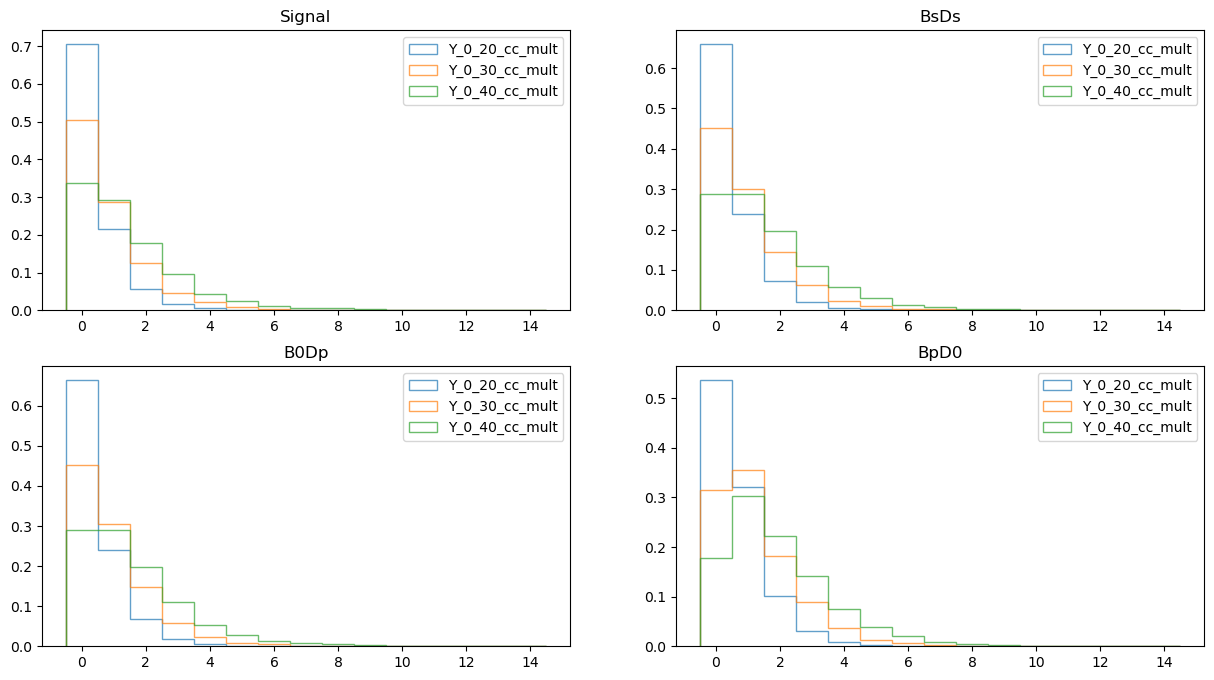

In [5]:
def hist(ax, *p, **k):
    k |= { 'histtype':'step', 'range':[-0.5, 14.5], 'bins':15,  'density':True, 'alpha':0.7}
    k['label'] = p[0].name
    _, bins, _ = ax.hist(*p, **k)
    ax.legend()

fig, axs = plt.subplots(2,2)
axs[0, 0].set_title("Signal")
axs[0, 1].set_title("BsDs")
axs[1, 0].set_title("B0Dp")
axs[1, 1].set_title("BpD0")

hist(axs[0, 0], df_signal.Y_0_20_cc_mult)
hist(axs[0, 1], df_disp_BsDs.Y_0_20_cc_mult)
hist(axs[1, 0], df_disp_B0Dp.Y_0_20_cc_mult)
hist(axs[1, 1], df_disp_BpD0.Y_0_20_cc_mult)

hist(axs[0, 0], df_signal.Y_0_30_cc_mult)
hist(axs[0, 1], df_disp_BsDs.Y_0_30_cc_mult)
hist(axs[1, 0], df_disp_B0Dp.Y_0_30_cc_mult)
hist(axs[1, 1], df_disp_BpD0.Y_0_30_cc_mult)


hist(axs[0, 0], df_signal.Y_0_40_cc_mult)
hist(axs[0, 1], df_disp_BsDs.Y_0_40_cc_mult)
hist(axs[1, 0], df_disp_B0Dp.Y_0_40_cc_mult)
hist(axs[1, 1], df_disp_BpD0.Y_0_40_cc_mult)


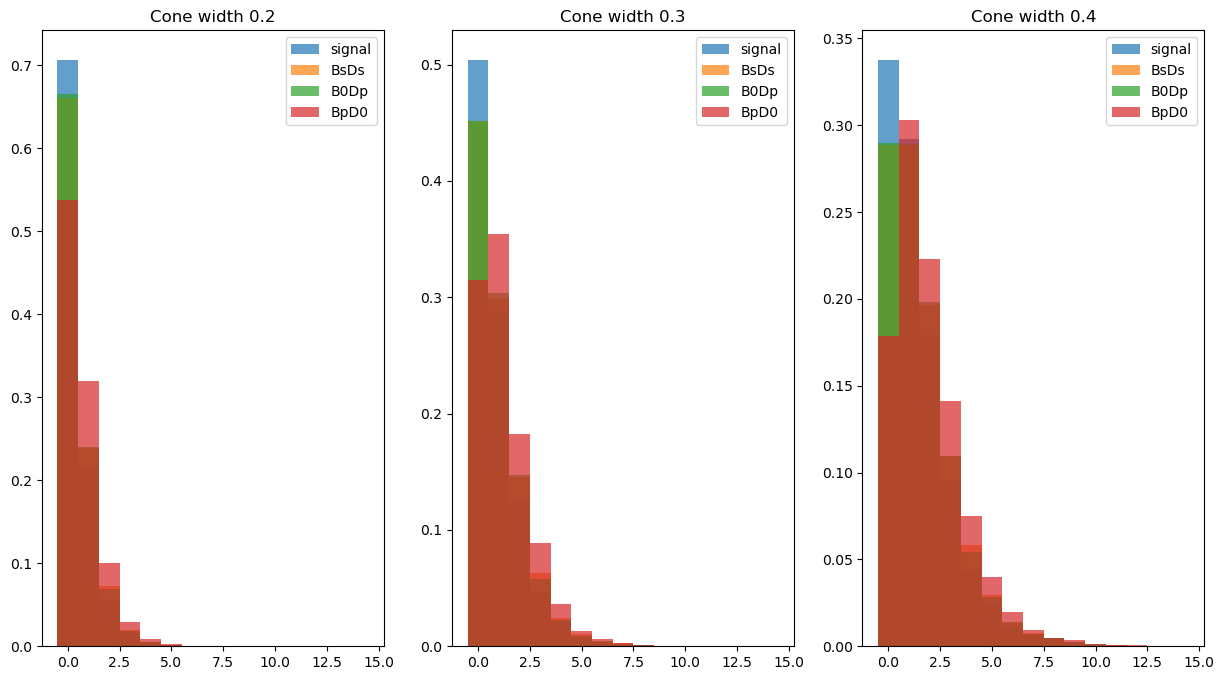

In [6]:
def hist(ax, *p, **k):
    k |= { 'histtype':'stepfilled', 'range':[-0.5, 14.5], 'bins':15,  'density':True, 'alpha':0.7}
    _, bins, _ = ax.hist(*p, **k)
    ax.legend()

fig, axs = plt.subplots(1,3)
axs[0].set_title("Cone width 0.2")
axs[1].set_title("Cone width 0.3")
axs[2].set_title("Cone width 0.4")


hist(axs[0], df_signal.Y_0_20_cc_mult, label="signal")
hist(axs[0], df_disp_BsDs.Y_0_20_cc_mult, label="BsDs")
hist(axs[0], df_disp_B0Dp.Y_0_20_cc_mult, label="B0Dp")
hist(axs[0], df_disp_BpD0.Y_0_20_cc_mult, label="BpD0")

hist(axs[1], df_signal.Y_0_30_cc_mult, label="signal")
hist(axs[1], df_disp_BsDs.Y_0_30_cc_mult, label="BsDs")
hist(axs[1], df_disp_B0Dp.Y_0_30_cc_mult, label="B0Dp")
hist(axs[1], df_disp_BpD0.Y_0_30_cc_mult, label="BpD0")


hist(axs[2], df_signal.Y_0_40_cc_mult, label="signal")
hist(axs[2], df_disp_BsDs.Y_0_40_cc_mult, label="BsDs")
hist(axs[2], df_disp_B0Dp.Y_0_40_cc_mult, label="B0Dp")
hist(axs[2], df_disp_BpD0.Y_0_40_cc_mult, label="BpD0")

<AxesSubplot: >

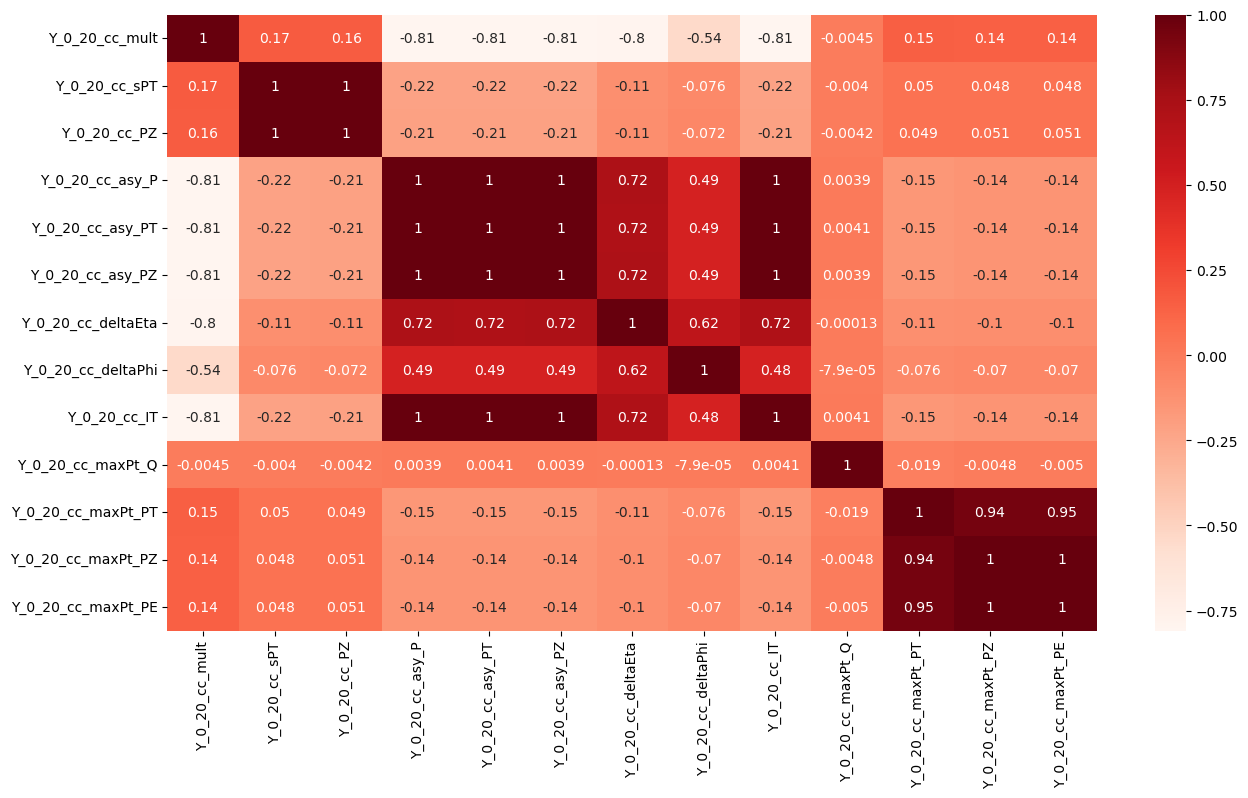

In [7]:
# myvars = ['Y_0_20_nc_mult', 'Y_0_20_nc_sPT', 'Y_0_20_nc_vPT', 'Y_0_20_nc_PX', 'Y_0_20_nc_PY', 'Y_0_20_nc_PZ', 'Y_0_20_nc_avCL', 
#         'Y_0_20_nc_maxCL', 'Y_0_20_nc_asy_P', 'Y_0_20_nc_asy_PT', 'Y_0_20_nc_asy_PX', 'Y_0_20_nc_asy_PY', 'Y_0_20_nc_asy_PZ', 
#         'Y_0_20_nc_deltaEta', 'Y_0_20_nc_deltaPhi', 'Y_0_20_nc_IT', 'Y_0_20_nc_maxPt_PT', 'Y_0_20_nc_maxPt_PX', 
#         'Y_0_20_nc_maxPt_PY', 'Y_0_20_nc_maxPt_PZ', 'Y_0_20_nc_H1', 'Y_0_20_nc_H2', 'Y_0_20_nc_H3', 'Y_0_20_nc_H4']
myvars = ['Y_0_20_cc_mult', 'Y_0_20_cc_sPT', 'Y_0_20_cc_vPT', 'Y_0_20_cc_PX', 'Y_0_20_cc_PY', 'Y_0_20_cc_PZ', 
          'Y_0_20_cc_asy_P', 'Y_0_20_cc_asy_PT', 'Y_0_20_cc_asy_PX', 'Y_0_20_cc_asy_PY', 'Y_0_20_cc_asy_PZ', 'Y_0_20_cc_deltaEta', 
          'Y_0_20_cc_deltaPhi', 'Y_0_20_cc_IT', 'Y_0_20_cc_maxPt_Q', 'Y_0_20_cc_maxPt_PT', 'Y_0_20_cc_maxPt_PX', 
          'Y_0_20_cc_maxPt_PY', 'Y_0_20_cc_maxPt_PZ', 'Y_0_20_cc_maxPt_PE']
myvars = ['Y_0_20_cc_mult', 'Y_0_20_cc_sPT', 'Y_0_20_cc_PZ', 
          'Y_0_20_cc_asy_P', 'Y_0_20_cc_asy_PT', 'Y_0_20_cc_asy_PZ', 'Y_0_20_cc_deltaEta', 
          'Y_0_20_cc_deltaPhi', 'Y_0_20_cc_IT', 'Y_0_20_cc_maxPt_Q', 'Y_0_20_cc_maxPt_PT', 'Y_0_20_cc_maxPt_PZ', 'Y_0_20_cc_maxPt_PE']
scor = df_signal[myvars].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds)

<AxesSubplot: >

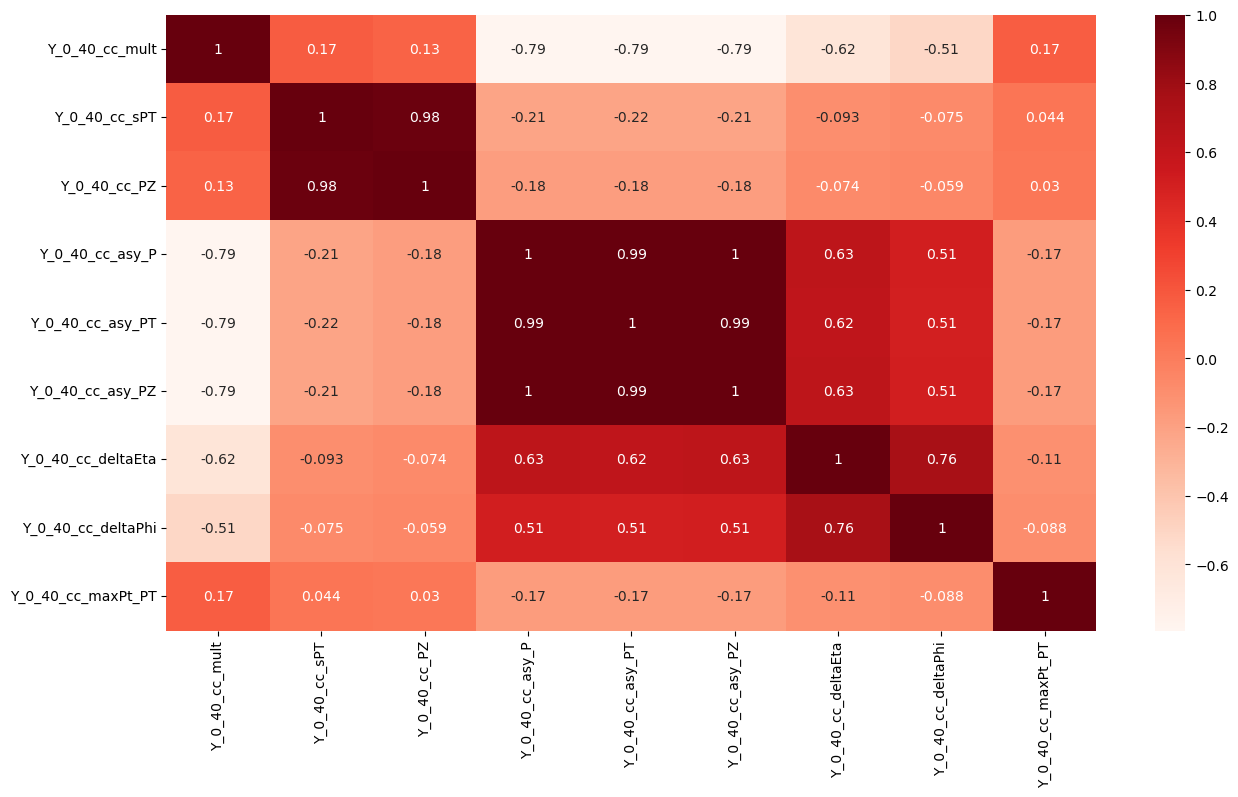

In [8]:
myvars = ['Y_0_40_cc_mult', 'Y_0_40_cc_sPT', 'Y_0_40_cc_PZ', 
          'Y_0_40_cc_asy_P', 'Y_0_40_cc_asy_PT', 'Y_0_40_cc_asy_PZ', 'Y_0_40_cc_deltaEta', 
          'Y_0_40_cc_deltaPhi',  'Y_0_40_cc_maxPt_PT']
scor = df_signal[myvars].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds)

<AxesSubplot: >

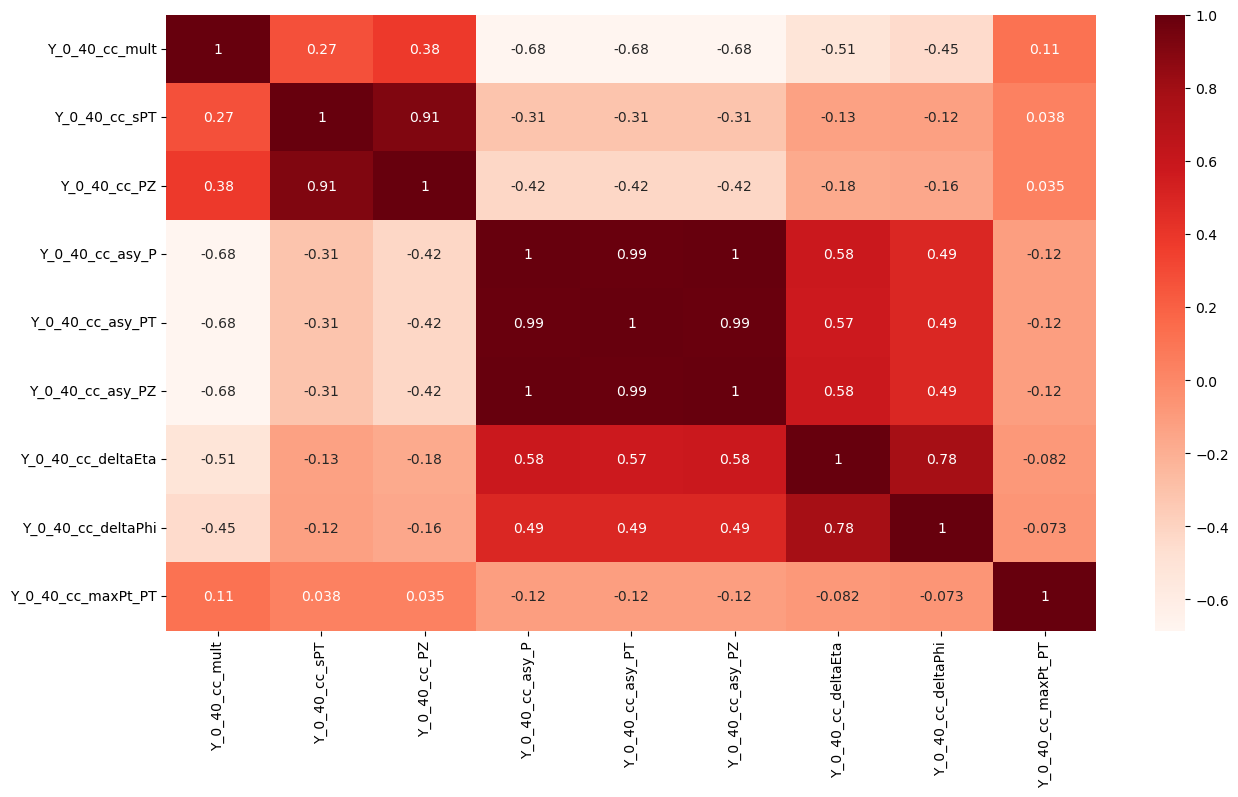

In [9]:
scor = df_disp_BpD0[myvars].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds)

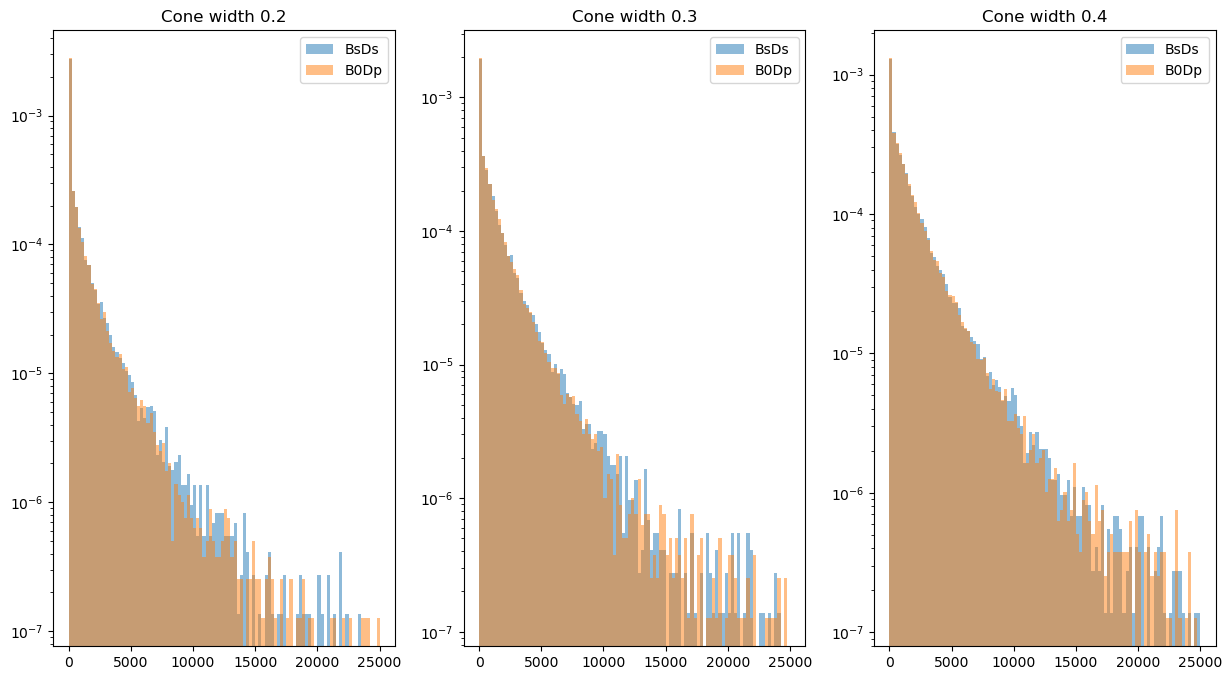

In [10]:
def hist(ax, *p, **k):
    k |= { 'histtype':'stepfilled', 'range':[0, 25000], 'bins':100, 'density':True, 'alpha':0.5}
    _, bins, _ = ax.hist(*p, **k)
    ax.legend()

fig, axs = plt.subplots(1,3)
axs[0].set_title("Cone width 0.2")
axs[0].set_yscale('log')
axs[1].set_title("Cone width 0.3")
axs[1].set_yscale('log')
axs[2].set_title("Cone width 0.4")
axs[2].set_yscale('log')


# hist(axs[0], df_disp_BpD0.Y_0_20_cc_sPT, label="BpD0")
# hist(axs[0], df_signal.Y_0_20_cc_sPT, label="signal")
hist(axs[0], df_disp_BsDs.Y_0_20_cc_sPT, label="BsDs")
hist(axs[0], df_disp_B0Dp.Y_0_20_cc_sPT, label="B0Dp")

# hist(axs[1], df_disp_BpD0.Y_0_30_cc_sPT, label="BpD0")
# hist(axs[1], df_signal.Y_0_30_cc_sPT, label="signal")
hist(axs[1], df_disp_BsDs.Y_0_30_cc_sPT, label="BsDs")
hist(axs[1], df_disp_B0Dp.Y_0_30_cc_sPT, label="B0Dp")


# hist(axs[2], df_disp_BpD0.Y_0_40_cc_sPT, label="BpD0")
# hist(axs[2], df_signal.Y_0_40_cc_sPT, label="signal")
hist(axs[2], df_disp_BsDs.Y_0_40_cc_sPT, label="BsDs")
hist(axs[2], df_disp_B0Dp.Y_0_40_cc_sPT, label="B0Dp")


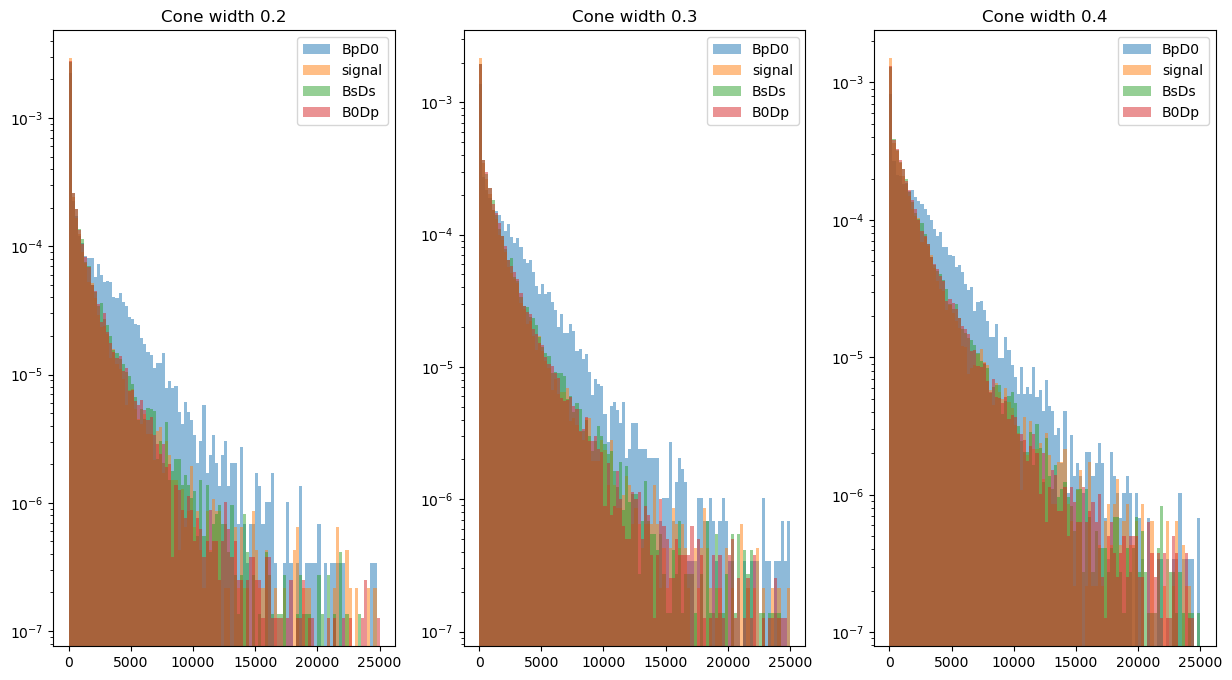

In [11]:
def hist(ax, *p, **k):
    k |= { 'histtype':'stepfilled', 'range':[0, 25000], 'bins':100, 'density':True, 'alpha':0.5}
    _, bins, _ = ax.hist(*p, **k)
    ax.legend()

fig, axs = plt.subplots(1,3)
axs[0].set_title("Cone width 0.2")
axs[0].set_yscale('log')
axs[1].set_title("Cone width 0.3")
axs[1].set_yscale('log')
axs[2].set_title("Cone width 0.4")
axs[2].set_yscale('log')


hist(axs[0], df_disp_BpD0.Y_0_20_cc_vPT, label="BpD0")
hist(axs[0], df_signal.Y_0_20_cc_vPT, label="signal")
hist(axs[0], df_disp_BsDs.Y_0_20_cc_vPT, label="BsDs")
hist(axs[0], df_disp_B0Dp.Y_0_20_cc_vPT, label="B0Dp")

hist(axs[1], df_disp_BpD0.Y_0_30_cc_vPT, label="BpD0")
hist(axs[1], df_signal.Y_0_30_cc_vPT, label="signal")
hist(axs[1], df_disp_BsDs.Y_0_30_cc_vPT, label="BsDs")
hist(axs[1], df_disp_B0Dp.Y_0_30_cc_vPT, label="B0Dp")


hist(axs[2], df_disp_BpD0.Y_0_40_cc_vPT, label="BpD0")
hist(axs[2], df_signal.Y_0_40_cc_vPT, label="signal")
hist(axs[2], df_disp_BsDs.Y_0_40_cc_vPT, label="BsDs")
hist(axs[2], df_disp_B0Dp.Y_0_40_cc_vPT, label="B0Dp")

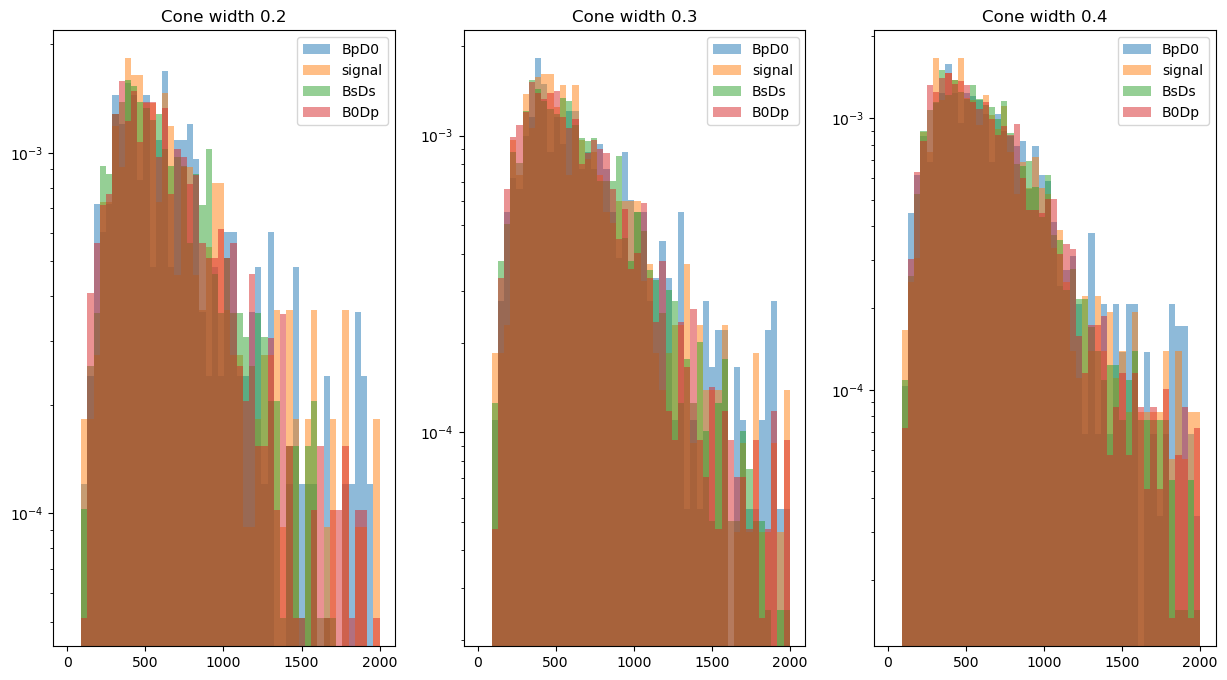

In [12]:
def hist(ax, *p, **k):
    k |= { 'histtype':'stepfilled', 'range':[10, 2000], 'bins':50, 'density':True, 'alpha':0.5}
    _, bins, _ = ax.hist(*p, **k)
    ax.legend()

fig, axs = plt.subplots(1,3)
axs[0].set_title("Cone width 0.2")
axs[0].set_yscale('log')
axs[1].set_title("Cone width 0.3")
axs[1].set_yscale('log')
axs[2].set_title("Cone width 0.4")
axs[2].set_yscale('log')


hist(axs[0], df_disp_BpD0.Y_0_20_cc_maxPt_PT, label="BpD0")
hist(axs[0], df_signal.Y_0_20_cc_maxPt_PT, label="signal")
hist(axs[0], df_disp_BsDs.Y_0_20_cc_maxPt_PT, label="BsDs")
hist(axs[0], df_disp_B0Dp.Y_0_20_cc_maxPt_PT, label="B0Dp")

hist(axs[1], df_disp_BpD0.Y_0_30_cc_maxPt_PT, label="BpD0")
hist(axs[1], df_signal.Y_0_30_cc_maxPt_PT, label="signal")
hist(axs[1], df_disp_BsDs.Y_0_30_cc_maxPt_PT, label="BsDs")
hist(axs[1], df_disp_B0Dp.Y_0_30_cc_maxPt_PT, label="B0Dp")


hist(axs[2], df_disp_BpD0.Y_0_40_cc_maxPt_PT, label="BpD0")
hist(axs[2], df_signal.Y_0_40_cc_maxPt_PT, label="signal")
hist(axs[2], df_disp_BsDs.Y_0_40_cc_maxPt_PT, label="BsDs")
hist(axs[2], df_disp_B0Dp.Y_0_40_cc_maxPt_PT, label="B0Dp")

# Neutral cone isolation variables

<AxesSubplot: >

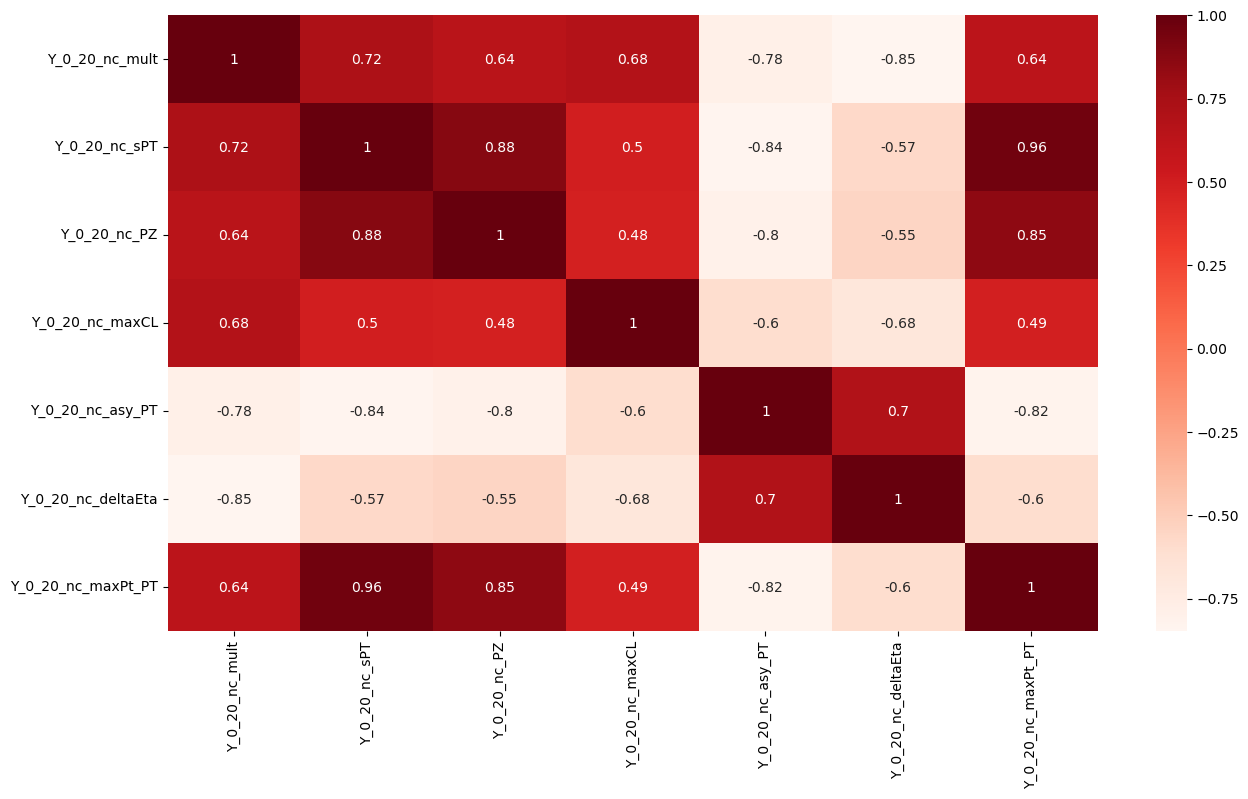

In [13]:
myvars = ['Y_0_20_nc_mult', 'Y_0_20_nc_sPT', 'Y_0_20_nc_PZ', 
        'Y_0_20_nc_maxCL', 'Y_0_20_nc_asy_PT', 
        'Y_0_20_nc_deltaEta',  'Y_0_20_nc_maxPt_PT']
scor = df_signal[myvars].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds)

<AxesSubplot: >

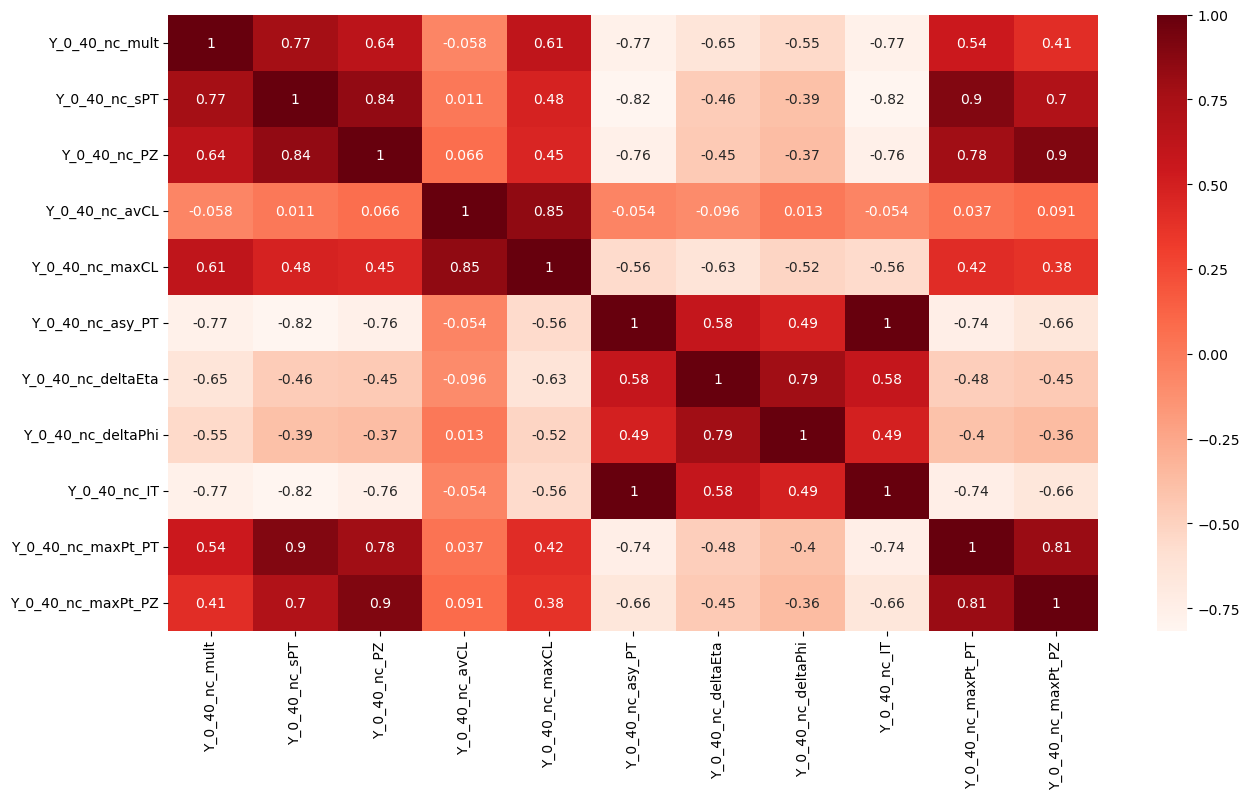

In [14]:
myvars = ['Y_0_40_nc_mult', 'Y_0_40_nc_sPT', 'Y_0_40_nc_PZ', 'Y_0_40_nc_avCL', 
        'Y_0_40_nc_maxCL', 'Y_0_40_nc_asy_PT', 
        'Y_0_40_nc_deltaEta', 'Y_0_40_nc_deltaPhi', 'Y_0_40_nc_IT', 'Y_0_40_nc_maxPt_PT',  
         'Y_0_40_nc_maxPt_PZ']
scor = df_signal[myvars].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds)

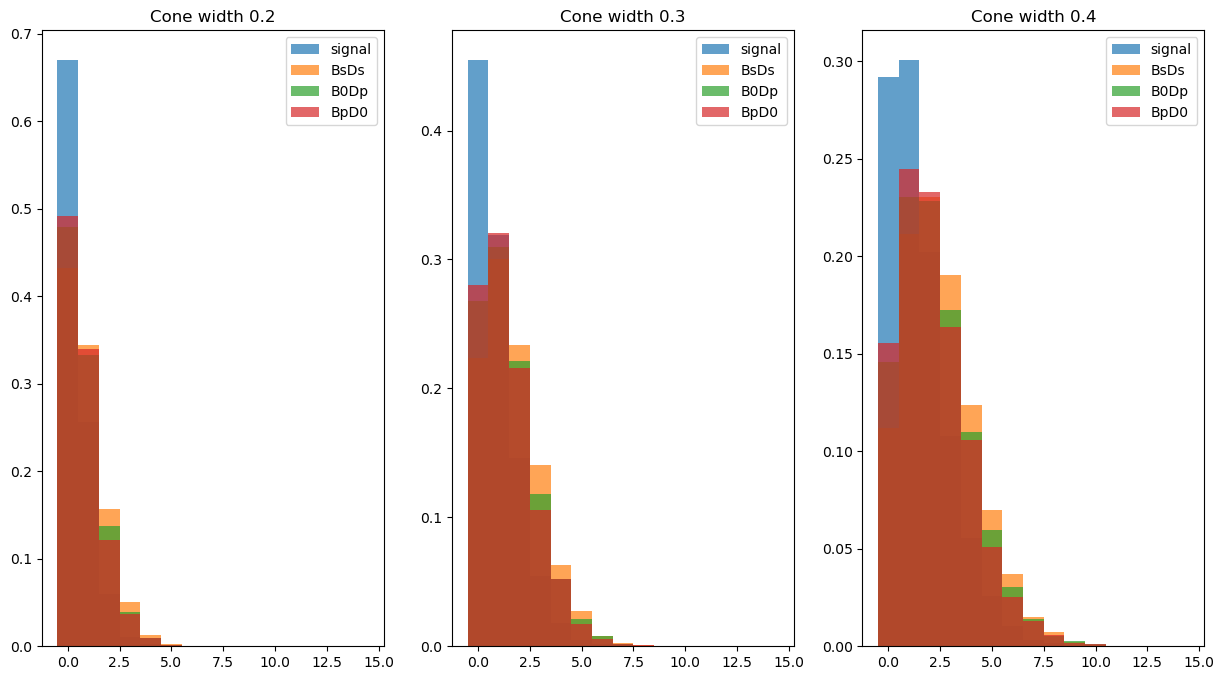

In [15]:
def hist(ax, *p, **k):
    k |= { 'histtype':'stepfilled', 'range':[-0.5, 14.5], 'bins':15,  'density':True, 'alpha':0.7}
    _, bins, _ = ax.hist(*p, **k)
    ax.legend()

fig, axs = plt.subplots(1,3)
axs[0].set_title("Cone width 0.2")
axs[1].set_title("Cone width 0.3")
axs[2].set_title("Cone width 0.4")


hist(axs[0], df_signal.Y_0_20_nc_mult, label="signal")
hist(axs[0], df_disp_BsDs.Y_0_20_nc_mult, label="BsDs")
hist(axs[0], df_disp_B0Dp.Y_0_20_nc_mult, label="B0Dp")
hist(axs[0], df_disp_BpD0.Y_0_20_nc_mult, label="BpD0")

hist(axs[1], df_signal.Y_0_30_nc_mult, label="signal")
hist(axs[1], df_disp_BsDs.Y_0_30_nc_mult, label="BsDs")
hist(axs[1], df_disp_B0Dp.Y_0_30_nc_mult, label="B0Dp")
hist(axs[1], df_disp_BpD0.Y_0_30_nc_mult, label="BpD0")


hist(axs[2], df_signal.Y_0_40_nc_mult, label="signal")
hist(axs[2], df_disp_BsDs.Y_0_40_nc_mult, label="BsDs")
hist(axs[2], df_disp_B0Dp.Y_0_40_nc_mult, label="B0Dp")
hist(axs[2], df_disp_BpD0.Y_0_40_nc_mult, label="BpD0")


# Correlations

## For the signal

<AxesSubplot: >

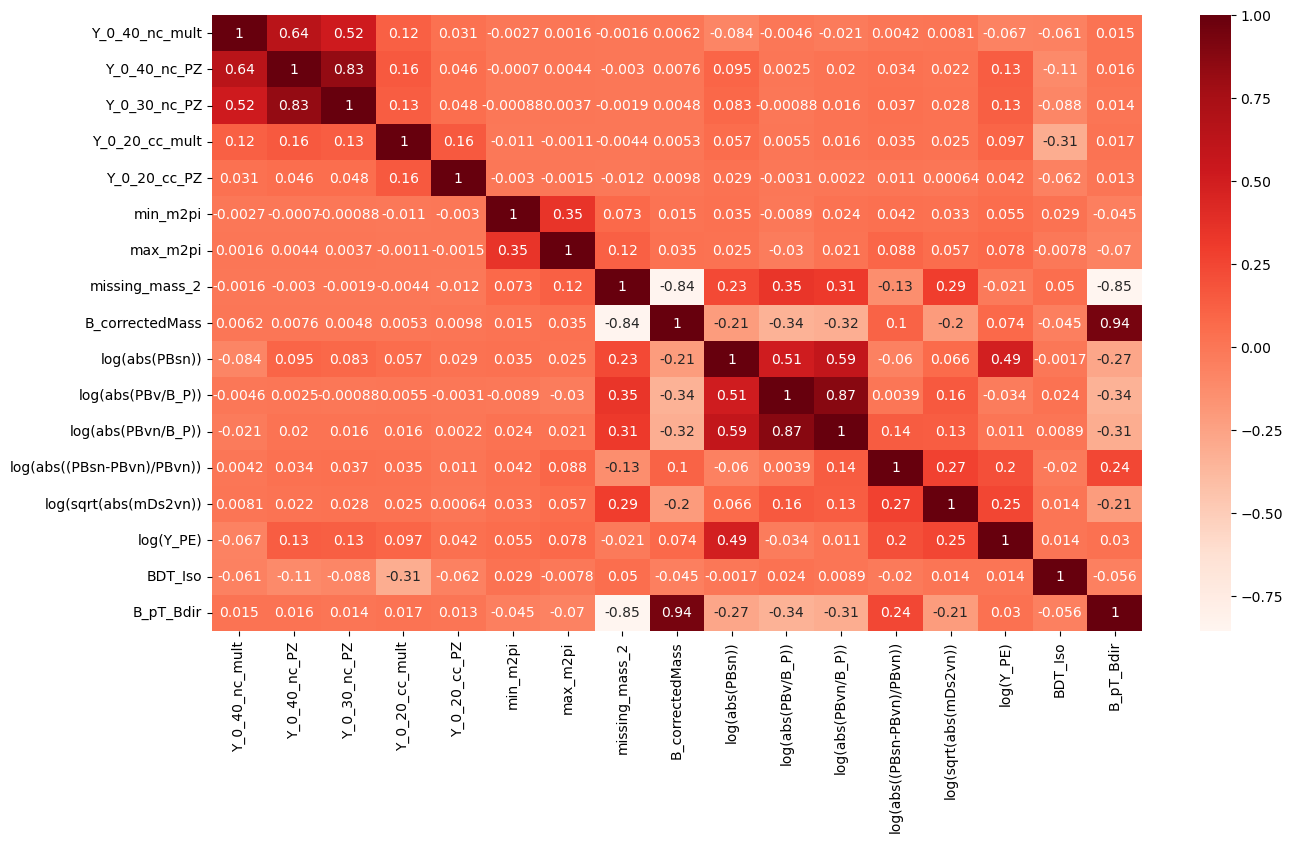

In [16]:
scor = df_signal[train_columns].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Reds)

# Dalitz plot checks

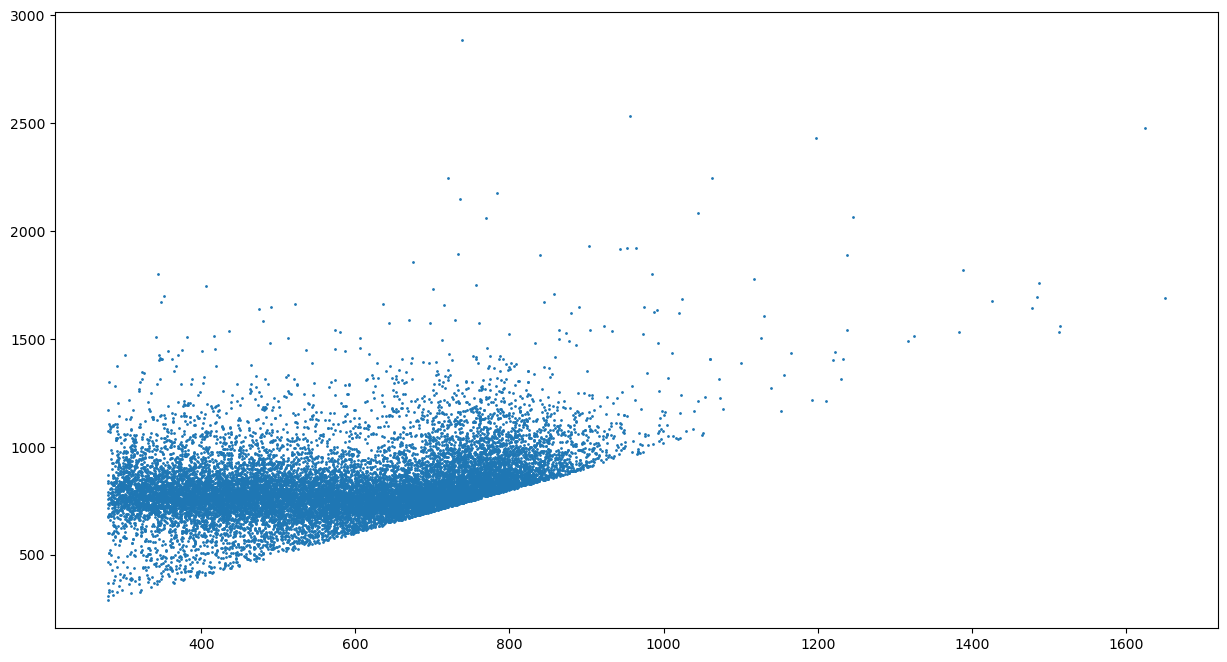

In [17]:
plt.scatter(df_signal.min_m2pi, df_signal.max_m2pi, s=1)

The structure in max_m2pi is due to the decay of the $\tau$ to rho via a1

max_m2pi is the mass of the 2 pion pair with higher mass
min_m2pi is the mass of the 2 pion pair with lower mass

when plotting them agaisnt each other one gets 

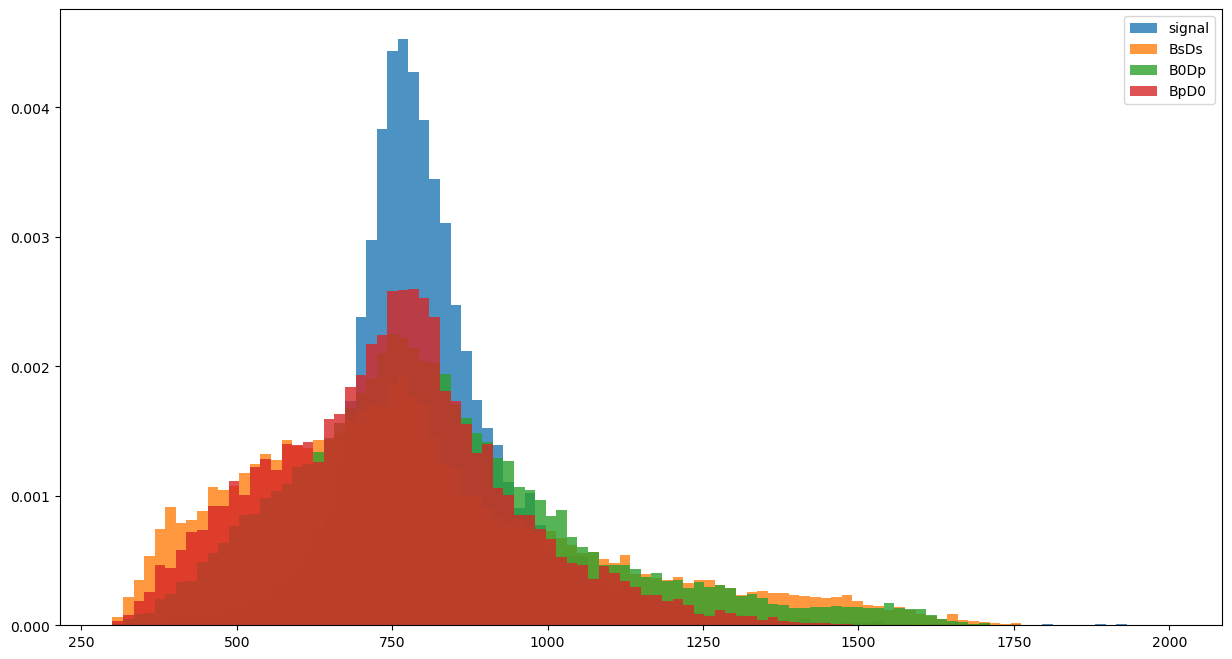

In [18]:
def hist(*p, **k):
    k |= { 'histtype':'bar', 'bins':100, 'range':[300, 2000], 'density':True, 'alpha':0.8}
    plt.hist(*p, **k)

hist(df_signal.max_m2pi, label="signal");
hist(df_disp_BsDs.max_m2pi, label="BsDs");
hist(df_disp_B0Dp.max_m2pi, label="B0Dp");
hist(df_disp_BpD0.max_m2pi, label="BpD0");
plt.legend();


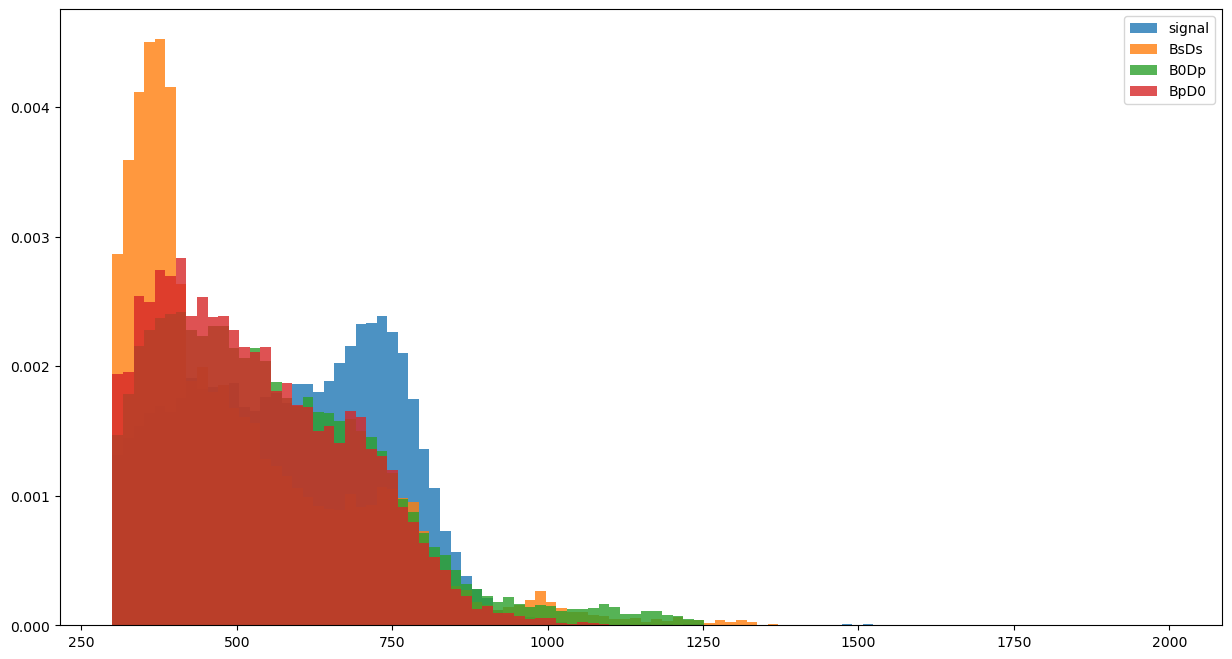

In [19]:
def hist(*p, **k):
    kargs = { 'histtype':'bar', 'bins':100, 'range':[300, 2000], 'density':True, 'alpha':0.8}
    kargs |= k
    plt.hist(*p, **kargs)

hist(df_signal.min_m2pi, label="signal")
hist(df_disp_BsDs.min_m2pi, label="BsDs")
hist(df_disp_B0Dp.min_m2pi, label="B0Dp")
hist(df_disp_BpD0.min_m2pi, label="BpD0")
plt.legend();


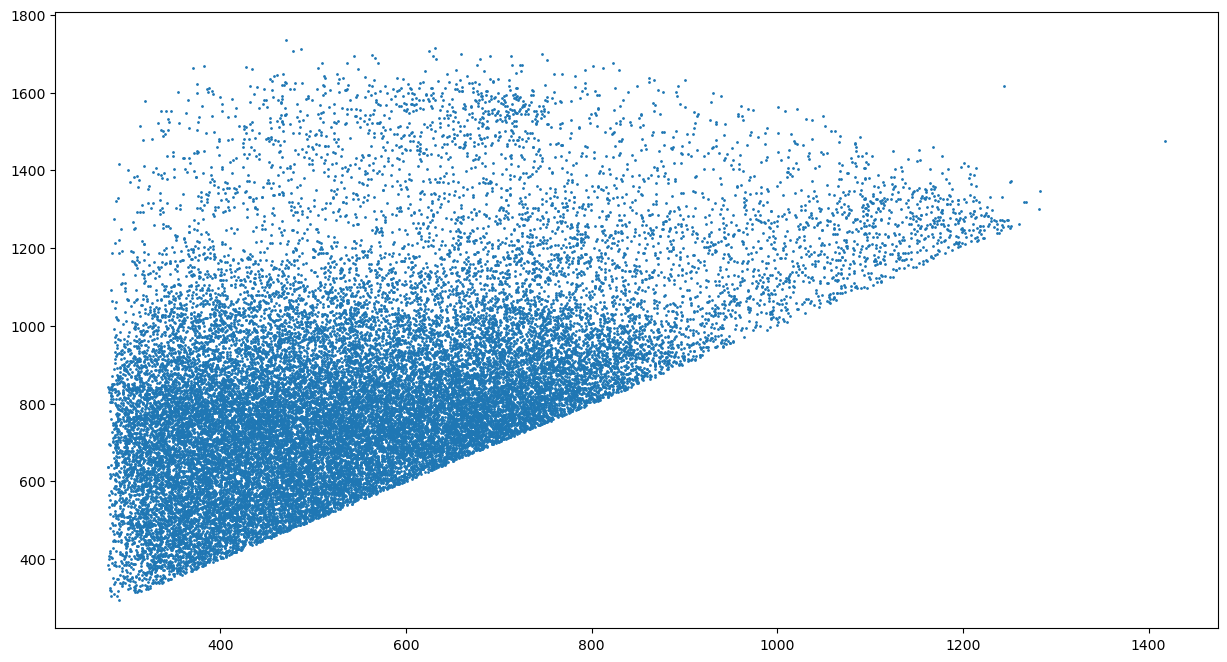

In [20]:
plt.scatter(df_disp_B0Dp.min_m2pi, df_disp_B0Dp.max_m2pi, s=1)

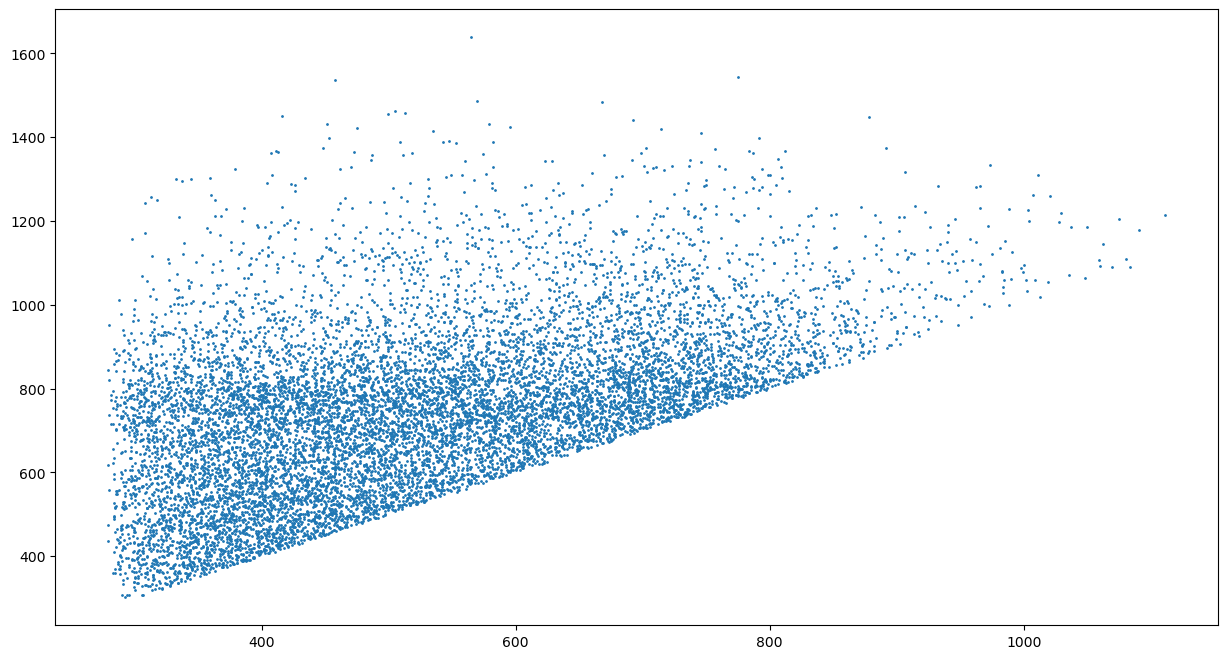

In [21]:
d =df_disp_BpD0
plt.scatter(d.min_m2pi, d.max_m2pi, s=1)

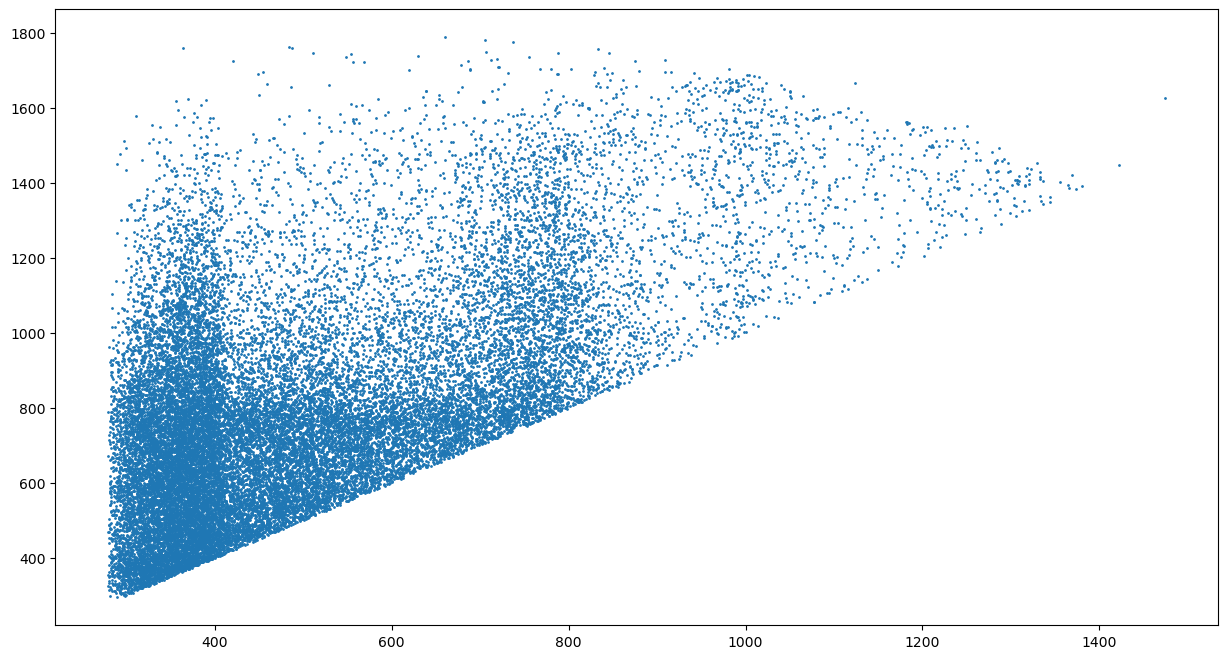

In [22]:
d = df_disp_BsDs
plt.scatter(d.min_m2pi, d.max_m2pi, s=1)

## BsDs

<AxesSubplot: >

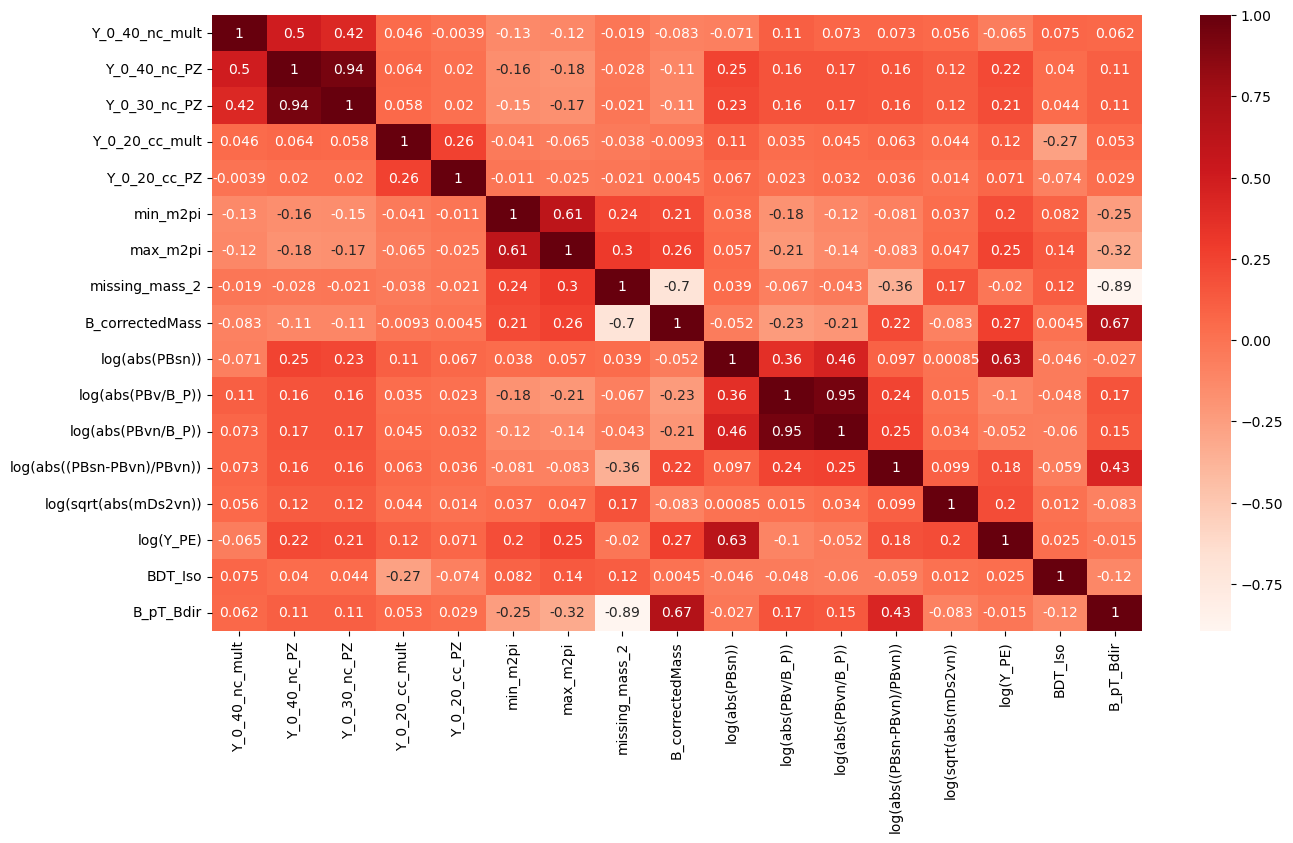

In [23]:
cor = df_disp_BsDs[train_columns].corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)

## signal + BsDs

<AxesSubplot: >

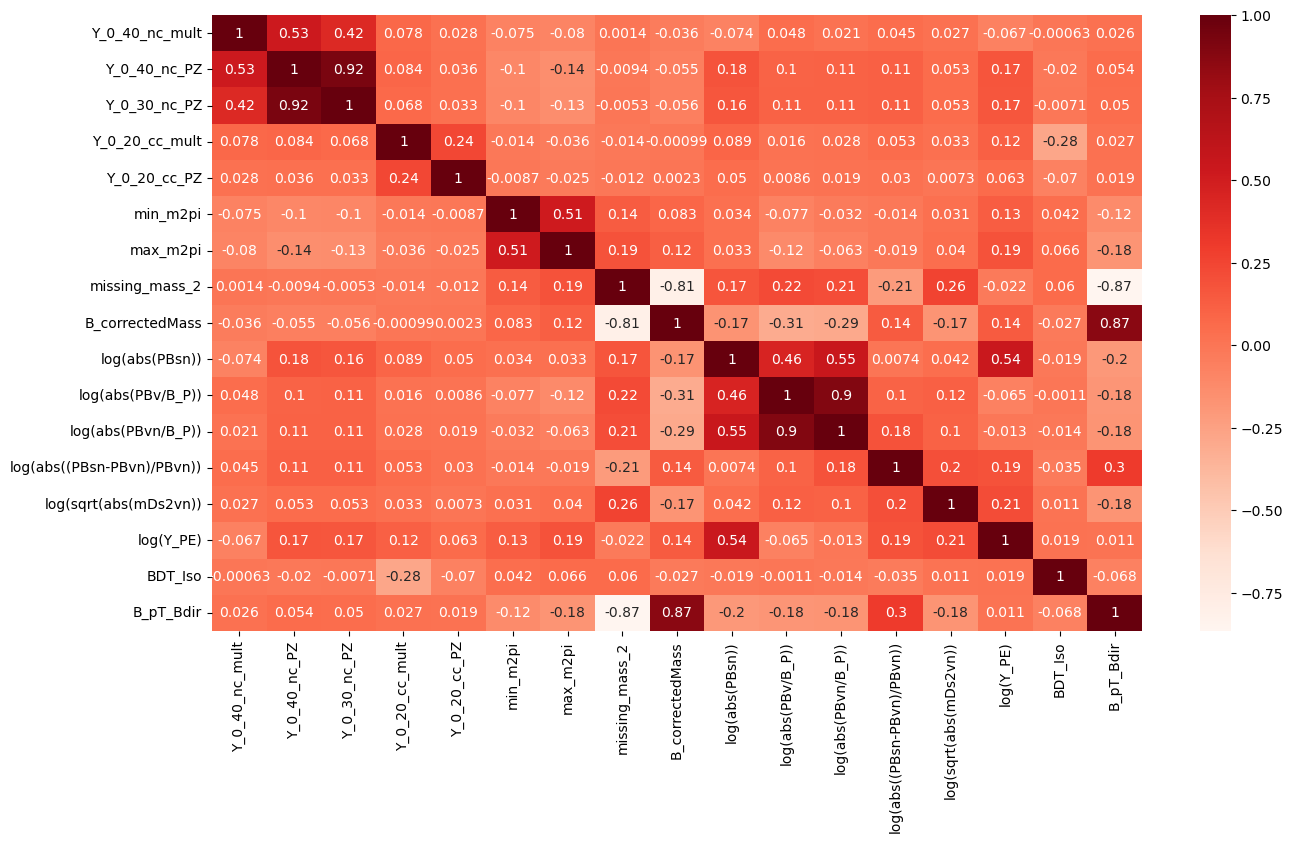

In [24]:
df = df_signal + df_disp_BsDs
cor = df[train_columns].corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)

# Preparing the data to train a classifier to separate signal and BpD0

In [25]:
#df_disp_BpD0["BpD0"] = 1
print(df_disp_BpD0.shape)
#df_other = pd.concat([df_disp_BsDs, df_disp_B0Dp], axis=0)
#df_other = pd.concat([df_signal], axis=0)
#df_other["BpD0"] = 0
df = pd.concat([df_disp_BpD0, df_signal], axis=0)
print(df.shape)
from sklearn.utils import shuffle
df = shuffle(df)

(11789, 152)
(30402, 152)


In [26]:
cc_columns_for_training = ["Y_0_40_cc_mult", "Y_0_40_cc_sPT", "Y_0_40_cc_asy_PT", 'Y_0_40_cc_deltaEta', 'Y_0_40_cc_maxPt_PT']
nc_columns_for_training =  ['Y_0_20_nc_mult', 'Y_0_20_nc_sPT', 'Y_0_20_nc_PZ', 'Y_0_20_nc_maxCL', 'Y_0_20_nc_asy_PT', 'Y_0_20_nc_deltaEta',  'Y_0_20_nc_maxPt_PT']
other = [ "min_m2pi", "max_m2pi", "missing_mass_2", "B_correctedMass"] \
        + ["log(abs(PBsn))", "log(abs(PBv/B_P))", "log(abs(PBvn/B_P))", "log(abs((PBsn-PBvn)/PBvn))", "log(sqrt(abs(mDs2vn))", "log(Y_PE)"] \
        + [ "BDT_Iso", "B_pT_Bdir", "Y_M"]
train_columns = other + cc_columns_for_training + nc_columns_for_training

In [27]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.25)

In [28]:
Xtrain = train[train_columns]
ytrain = train["signal"]
Xtest = test[train_columns]
ytest = test["signal"]

In [29]:
%%time
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(Xtrain)
Xtrain_scaled = scaler.transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)


CPU times: user 23.4 ms, sys: 0 ns, total: 23.4 ms
Wall time: 21.5 ms


# Now training 

In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(max_depth=5, n_estimators=50)
classifier = make_pipeline(StandardScaler(), clf)

In [31]:
%%time
classifier.fit(Xtrain, ytrain)

CPU times: user 1.29 s, sys: 0 ns, total: 1.29 s
Wall time: 1.29 s


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=5, n_estimators=50))])

In [32]:
# from sklearn.metrics import PrecisionRecallDisplay
# display = PrecisionRecallDisplay.from_estimator(
#     classifier, Xtest, ytest, name="RandomForest"
# )
# _ = display.ax_.set_title("2-class Precision-Recall curve")

0.8960760558985512


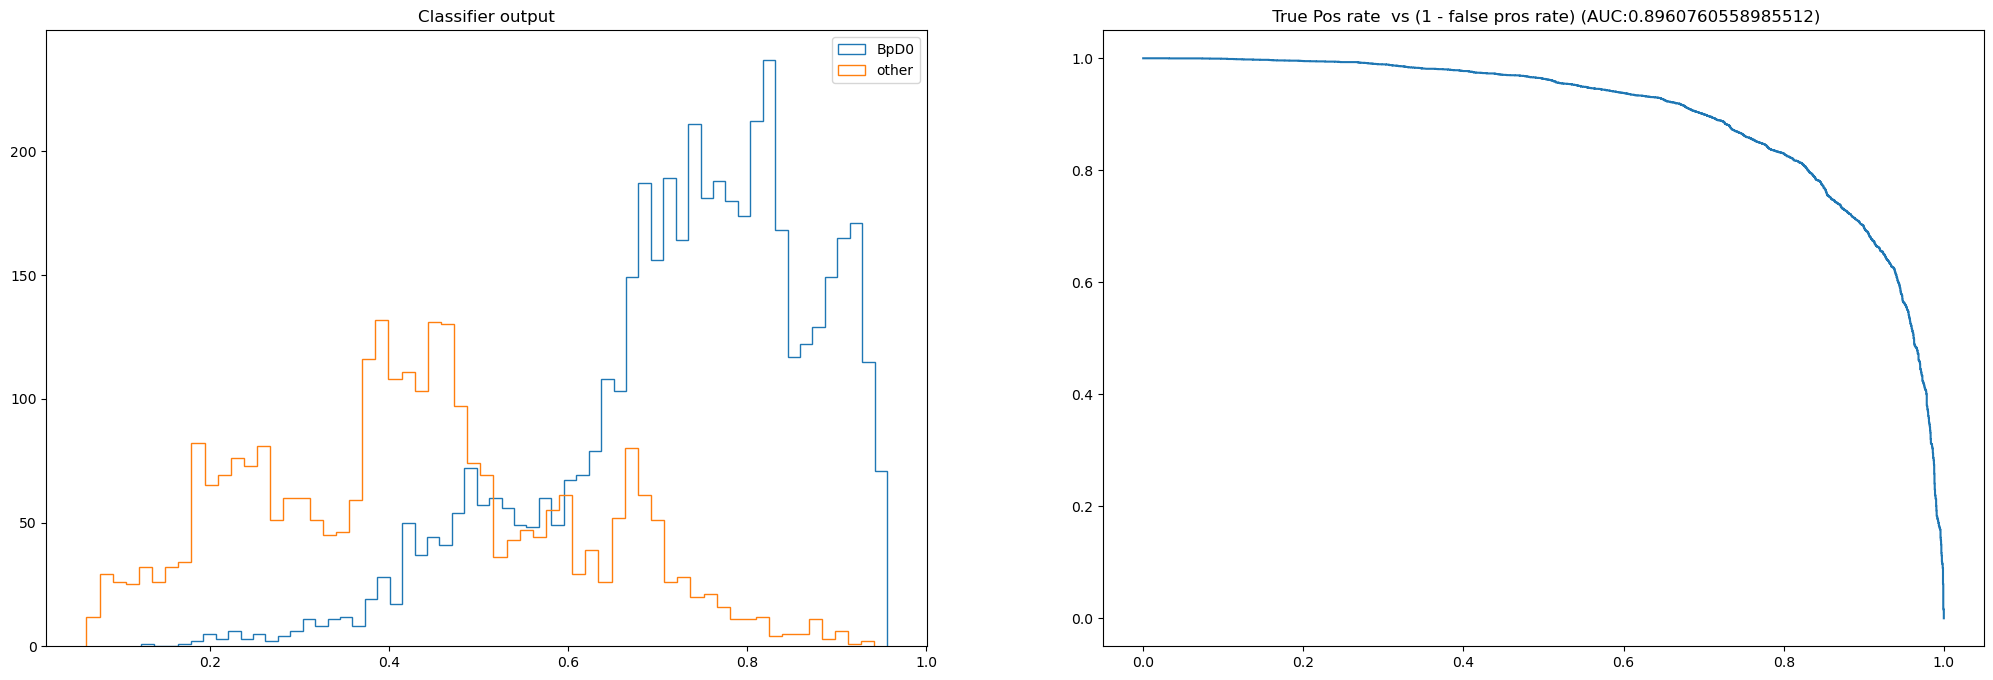

In [33]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = classifier.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='BpD0');
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='other');
ax1.legend();

In [34]:
ypred = clf.predict(Xtest)

/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-01-19_13-58/linux-64/lib/python3.9/site-packages/sklearn/base.py:402: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [35]:
print(ytest[ytest==0].shape)
print(ytest[ytest==1].shape)
classifier.get_params()

(2911,)
(4690,)


{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('randomforestclassifier',
   RandomForestClassifier(max_depth=5, n_estimators=50))],
 'verbose': False,
 'standardscaler': StandardScaler(),
 'randomforestclassifier': RandomForestClassifier(max_depth=5, n_estimators=50),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'randomforestclassifier__bootstrap': True,
 'randomforestclassifier__ccp_alpha': 0.0,
 'randomforestclassifier__class_weight': None,
 'randomforestclassifier__criterion': 'gini',
 'randomforestclassifier__max_depth': 5,
 'randomforestclassifier__max_features': 'sqrt',
 'randomforestclassifier__max_leaf_nodes': None,
 'randomforestclassifier__max_samples': None,
 'randomforestclassifier__min_impurity_decrease': 0.0,
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__min_samples_split': 2,
 'randomforestclassifier__min_weight_fraction_leaf': 0.0,
 'randomforestclassifier__n_esti

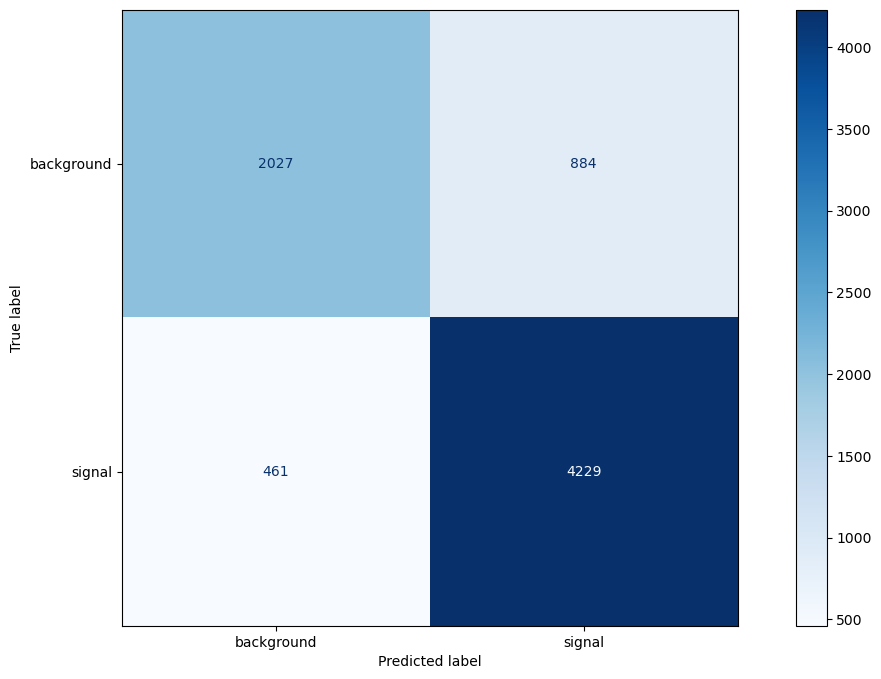

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion_matrix(ytest, ypred)
class_names = [ "background", "signal"]
classifier.set_params
ConfusionMatrixDisplay.from_estimator(
        classifier,
        Xtest,
        ytest,
        display_labels = class_names,
        cmap=plt.cm.Blues,
        normalize=None,
    )

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, ypred)

0.6492566767530588

In [38]:
sum(ytest == ypred)

4935

In [39]:
sum(ytest != ypred)

2666

In [40]:
#from sklearn.metrics import mean_squared_error
#mean_squared_error(ytest, ypred)

# Using xgboost

In [41]:
import xgboost as xgb

In [42]:
xg_reg = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgbclass = make_pipeline(StandardScaler(), xg_reg)

/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-01-19_13-58/linux-64/lib/python3.9/site-packages/xgboost/sklearn.py:1421: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [43]:
%%time
xgbclass.fit(Xtrain,ytrain)

CPU times: user 12.8 s, sys: 32.7 ms, total: 12.9 s
Wall time: 1.65 s


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
                               colsample_bylevel=1, colsample_bynode=1,
                               colsample_bytree=1, early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=0, gpu_id=-1,
                               grow_policy='depthwise', importance_type=None,
                               interaction_constraints='',
                               learning_rate=0.300000012, max_bin=256,
                               max_cat_threshold=64, max_cat_to_onehot=4,
                               max_delta_step=0, max_depth=6, max_leaves=0,
                               min_child_weight=1, missing=nan,
                               monotone_constraints='()', n_estimators=100,
                               n_jobs=0, num_parallel_tree=1, predictor='auto',
                               random_state=0, ...))])

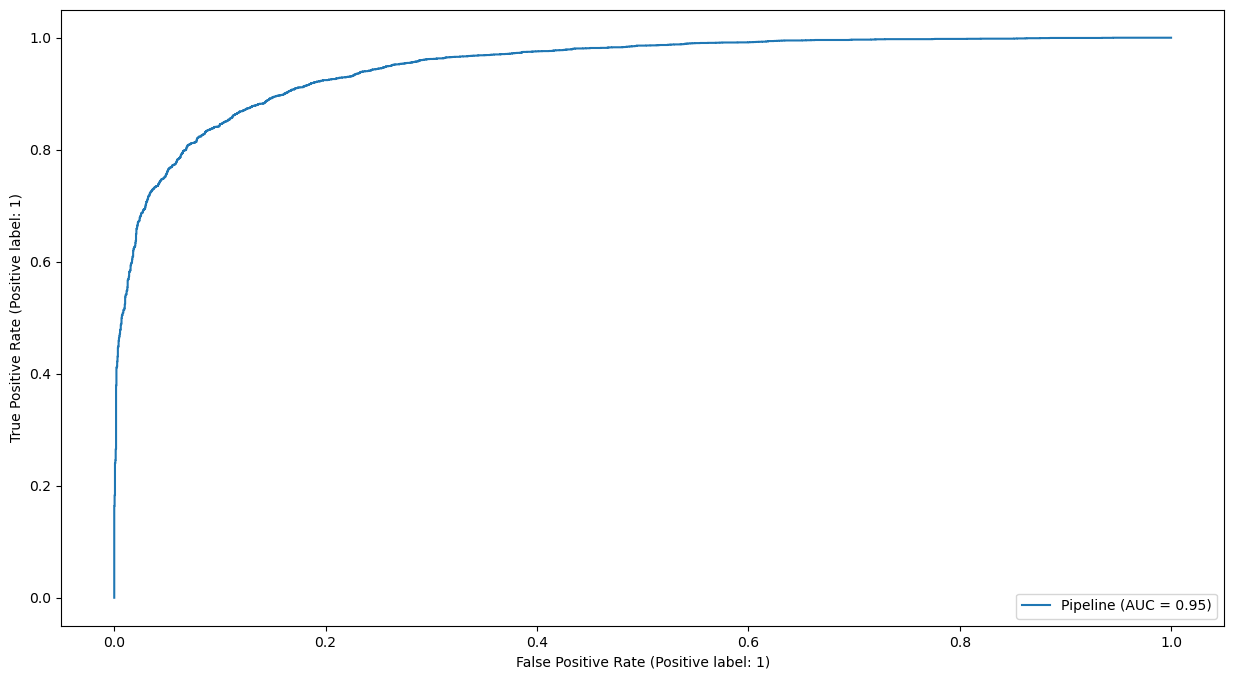

In [44]:
xgb_disp = RocCurveDisplay.from_estimator(xgbclass, Xtest, ytest)
plt.show()

In [45]:
from sklearn.metrics import confusion_matrix
ypred = xgbclass.predict(Xtest)
confusion_matrix(ytest, ypred)

array([[2431,  480],
       [ 452, 4238]])

In [46]:
yscore = xgbclass.predict_proba(Xtest)
yscore

array([[0.9702607 , 0.02973931],
       [0.99823993, 0.00176005],
       [0.02121675, 0.97878325],
       ...,
       [0.15885717, 0.84114283],
       [0.08834618, 0.9116538 ],
       [0.00479853, 0.99520147]], dtype=float32)

0.9484956334292615


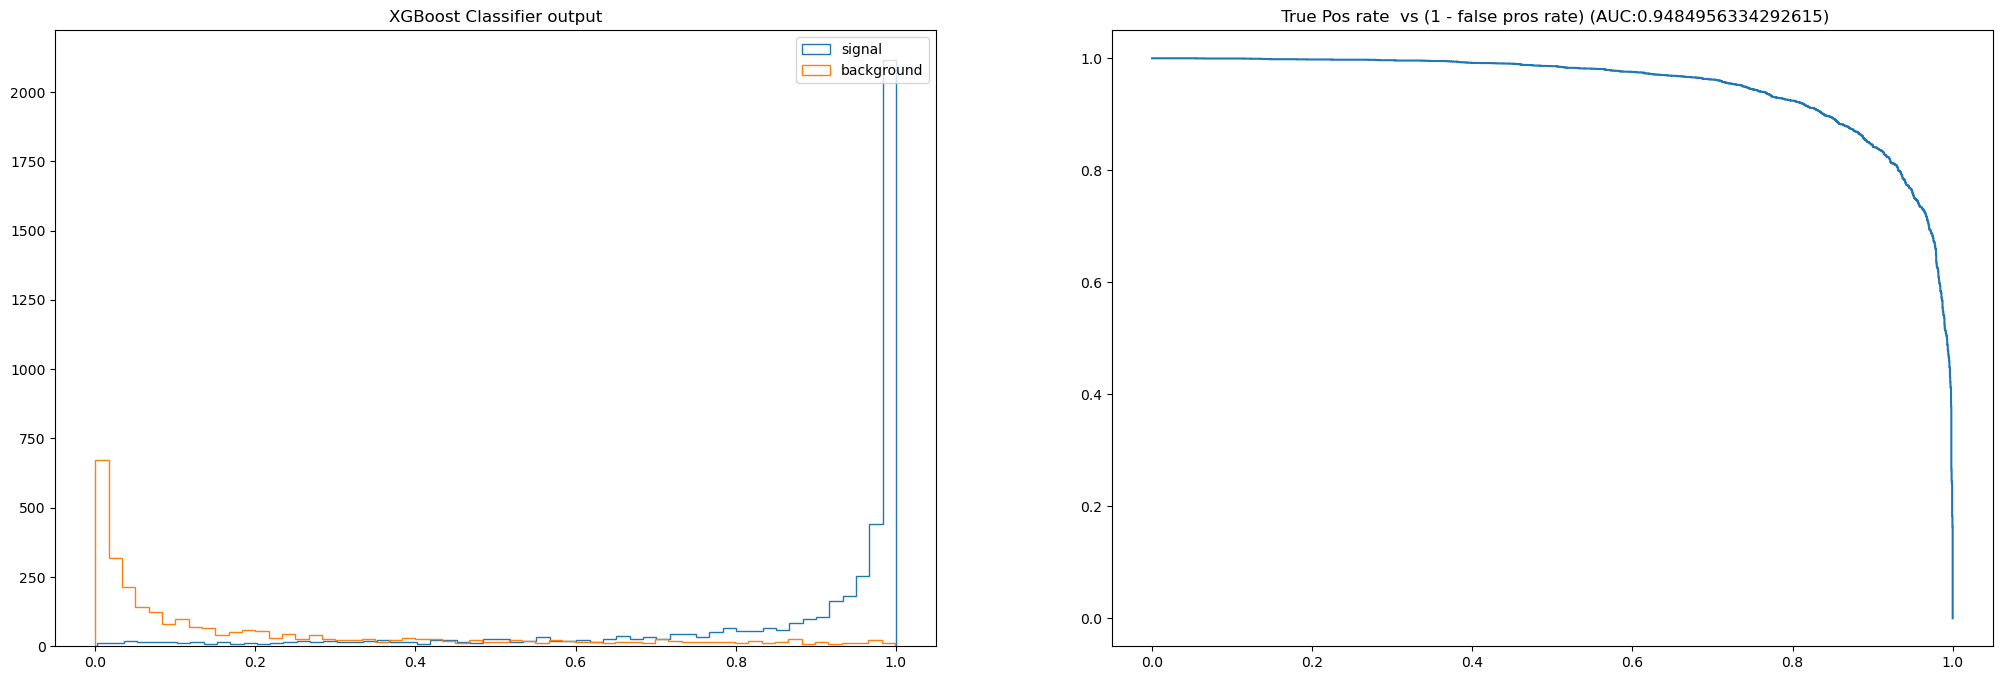

In [47]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = xgbclass.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal');
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background');
ax1.legend();

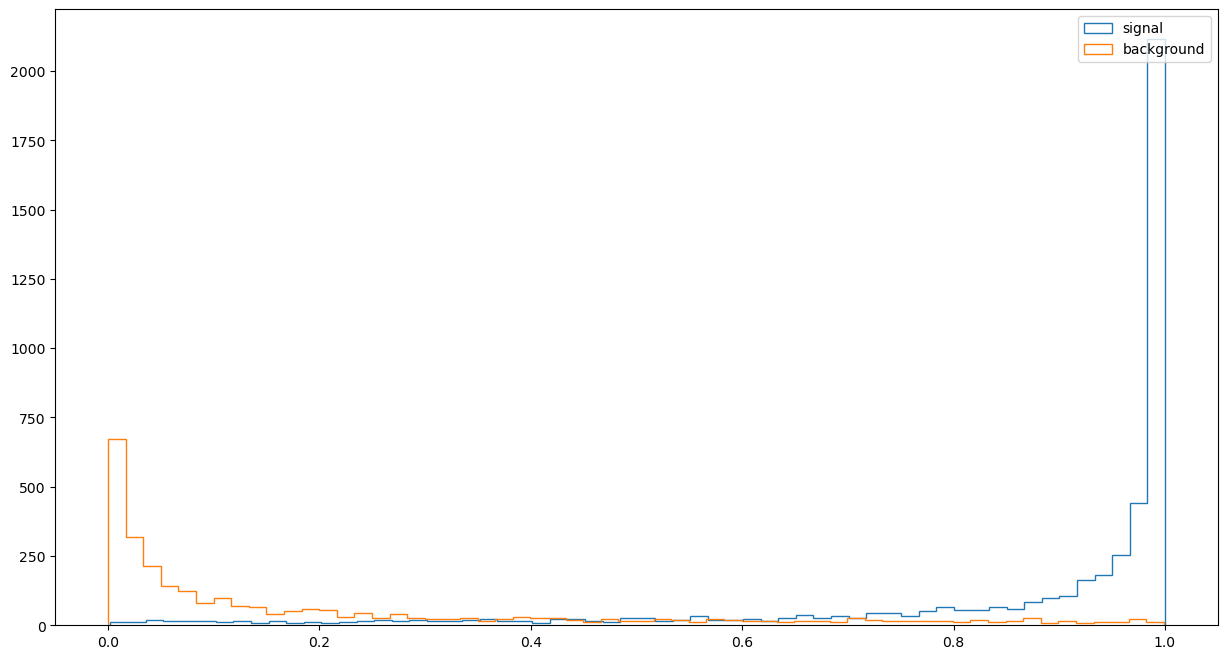

In [48]:
t = 'step'
n, bins, p = plt.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal');
plt.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background');
plt.legend();

# Preparing the data to train a classifier to separate signal and B0Dp/BsDs

In [49]:
from sklearn.utils import shuffle
df_background = pd.concat([df_disp_BsDs, df_disp_B0Dp], axis=0)
df_background= shuffle(df_background)
df_background = df_background.head(df_signal.shape[0])
df = pd.concat([df_signal,df_background], axis=0)
print(df[df["signal"]==1].shape)
print(df[df["signal"]==0].shape)

df = shuffle(df)

(18613, 152)
(18613, 152)


In [50]:
cc_columns_for_training = ["Y_0_40_cc_mult", "Y_0_40_cc_sPT", "Y_0_40_cc_asy_PT", 'Y_0_40_cc_deltaEta', 'Y_0_40_cc_maxPt_PT']
nc_columns_for_training =  ['Y_0_20_nc_mult', 'Y_0_20_nc_sPT', 'Y_0_20_nc_PZ', 'Y_0_20_nc_maxCL', 'Y_0_20_nc_asy_PT', 'Y_0_20_nc_deltaEta',  'Y_0_20_nc_maxPt_PT']
other = [ "min_m2pi", "max_m2pi", "missing_mass_2", "B_correctedMass"] \
        + ["log(abs(PBsn))", "log(abs(PBv/B_P))", "log(abs(PBvn/B_P))", "log(abs((PBsn-PBvn)/PBvn))", "log(sqrt(abs(mDs2vn))", "log(Y_PE)"] \
        + [ "BDT_Iso", "B_pT_Bdir", "Y_M"]
train_columns = other + cc_columns_for_training + nc_columns_for_training

In [51]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.25)

In [52]:
Xtrain = train[train_columns]
ytrain = train["signal"]
Xtest = test[train_columns]
ytest = test["signal"]

In [53]:
%%time
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(Xtrain)
Xtrain_scaled = scaler.transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)


CPU times: user 26.4 ms, sys: 0 ns, total: 26.4 ms
Wall time: 24 ms


In [54]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(max_depth=5, n_estimators=50)
classifier = make_pipeline(StandardScaler(), clf)

In [55]:
%%time
classifier.fit(Xtrain, ytrain)

CPU times: user 1.6 s, sys: 609 µs, total: 1.61 s
Wall time: 1.6 s


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=5, n_estimators=50))])

0.8883973339700377


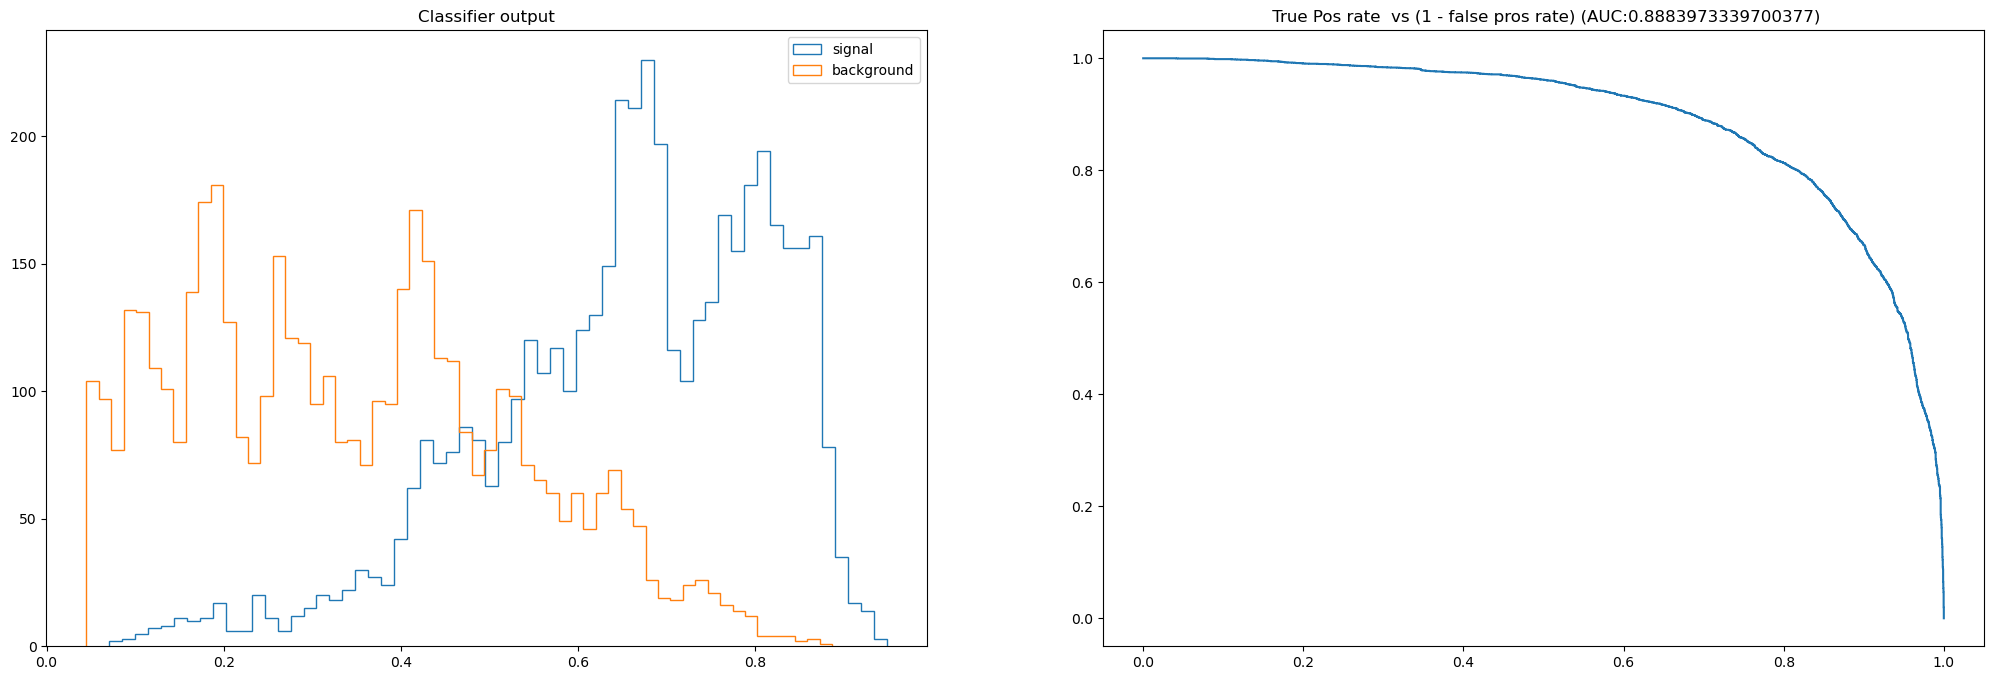

In [56]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = classifier.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal');
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background');
ax1.legend();

# Using xgboost

In [57]:
import xgboost as xgb

In [58]:
xg_reg = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgbclass = make_pipeline(StandardScaler(), xg_reg)

/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-01-19_13-58/linux-64/lib/python3.9/site-packages/xgboost/sklearn.py:1421: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [59]:
%%time
xgbclass.fit(Xtrain,ytrain)

CPU times: user 15.4 s, sys: 40.7 ms, total: 15.4 s
Wall time: 1.97 s


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
                               colsample_bylevel=1, colsample_bynode=1,
                               colsample_bytree=1, early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=0, gpu_id=-1,
                               grow_policy='depthwise', importance_type=None,
                               interaction_constraints='',
                               learning_rate=0.300000012, max_bin=256,
                               max_cat_threshold=64, max_cat_to_onehot=4,
                               max_delta_step=0, max_depth=6, max_leaves=0,
                               min_child_weight=1, missing=nan,
                               monotone_constraints='()', n_estimators=100,
                               n_jobs=0, num_parallel_tree=1, predictor='auto',
                               random_state=0, ...))])

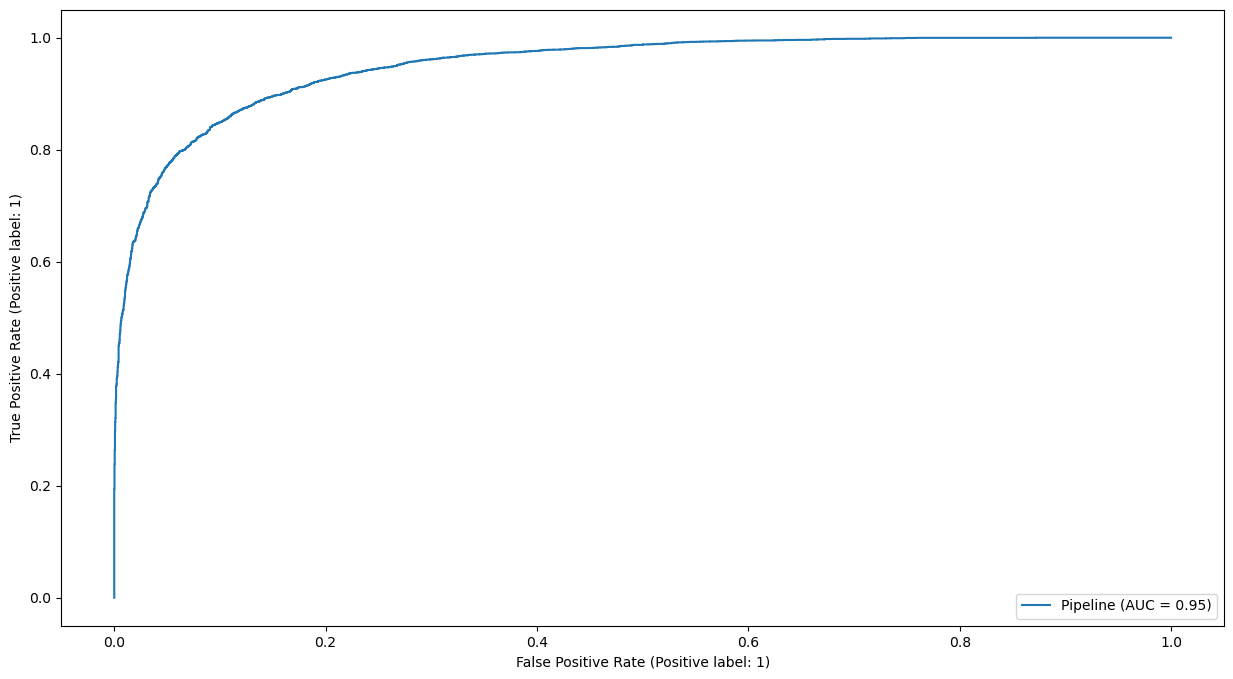

In [60]:
xgb_disp = RocCurveDisplay.from_estimator(xgbclass, Xtest, ytest)
plt.show()

In [61]:
from sklearn.metrics import confusion_matrix
ypred = xgbclass.predict(Xtest)
confusion_matrix(ytest, ypred)

array([[4059,  551],
       [ 604, 4093]])

In [62]:
yscore = xgbclass.predict_proba(Xtest)
yscore

array([[0.38033277, 0.61966723],
       [0.7790915 , 0.22090851],
       [0.6860044 , 0.31399557],
       ...,
       [0.90721965, 0.09278035],
       [0.8364423 , 0.16355772],
       [0.05684882, 0.9431512 ]], dtype=float32)

0.9502226925664925


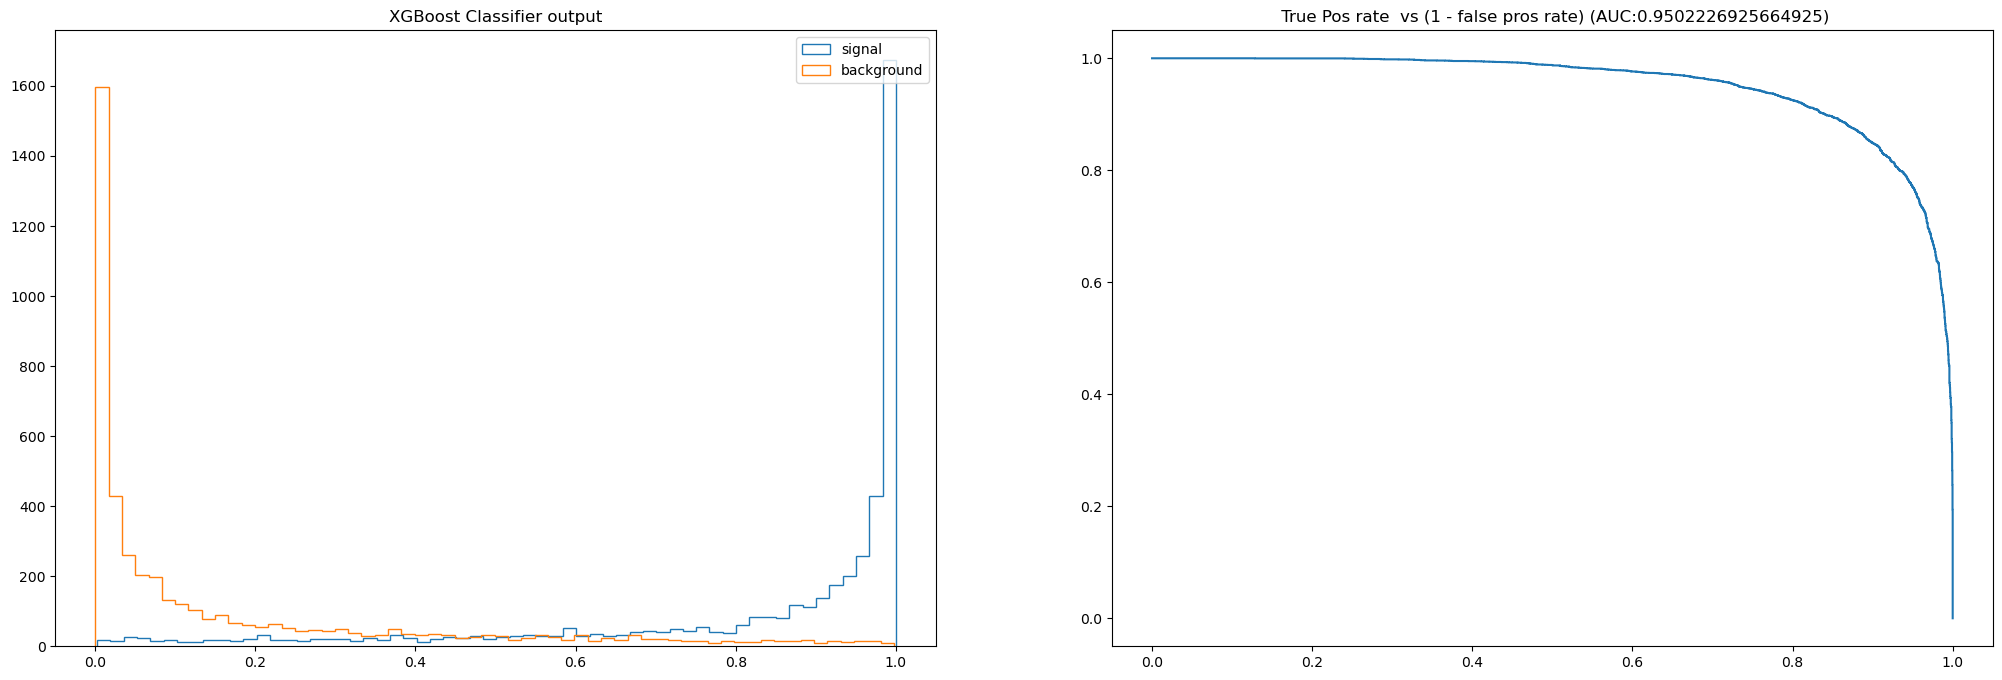

In [63]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = xgbclass.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal');
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background');
ax1.legend();

## Identifying normlike

In [64]:
# xg_reg2 = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
# xgbnormlike = make_pipeline(StandardScaler(), xg_reg2)

In [65]:
# from sklearn.model_selection import train_test_split
# train, test = train_test_split(df, test_size=0.2)
# Xtrain = train[["Y_M", "q2_2", "tauY_2", "B_MM", "B_Y_SEP"]]
# ytrain = train["normlike"]
# Xtest = test[["Y_M", "q2_2", "tauY_2", "B_MM", "B_Y_SEP"]]
# ytest = test["normlike"]

In [66]:
# %%time
# xgbclass.fit(Xtrain,ytrain)

In [67]:
# from sklearn.metrics import confusion_matrix
# ypred = xgbclass.predict(Xtest)
# confusion_matrix(ytest, ypred)

In [68]:
# confusion_matrix(ytest, ypred, normalize='all')

In [69]:
# from sklearn.model_selection import train_test_split
# train, test = train_test_split(df, test_size=0.2)
# Xtrain = train[["Y_M", "q2_2", "tauY_2", "B_MM", "B_Y_SEP"]]
# ytrain = train["doubleCharm"]
# Xtest = test[["Y_M", "q2_2", "tauY_2", "B_MM", "B_Y_SEP"]]
# ytest = test["doubleCharm"]

In [70]:
# xg_reg3 = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
# xgdc = make_pipeline(StandardScaler(), xg_reg3)

In [71]:
# %%time
# xgbclass.fit(Xtrain,ytrain)


In [72]:
# from sklearn.metrics import confusion_matrix
# ypred = xgbclass.predict(Xtest)
# confusion_matrix(ytest, ypred, normalize='all')